In [ ]:
!pip install ONE-api
!pip install iblatlas

# assume this is the PPSEQ REPO
# !pip install git+https://github.com/lindermanlab/ppseq-pytorch

  Cloning https://github.com/lindermanlab/ppseq-pytorch to /tmp/pip-req-build-qrl6rdd7
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ppseq-pytorch /tmp/pip-req-build-qrl6rdd7
  Resolved https://github.com/lindermanlab/ppseq-pytorch to commit 04b6e35a5f11453a2cf29bb520c0c95e08772bd2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# IBL PP-Seq + Decoding Analysis
# Phase 1: Data Setup and Sequence Detection

import numpy as np
import pandas as pd
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# IBL Data Access Setup
from one.api import ONE
from iblatlas.regions import BrainRegions
print("✓ IBL  imported successfully")

from ppseq.model import PPSeq
from ppseq.plotting import plot_model, color_plot


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


✓ IBL  imported successfully


In [ ]:
# config / global variables
eid = 'ebce500b-c530-47de-8cb1-963c552703ea'
REVISION = '2024-05-06'


In [ ]:
# Setup ONE API connection
print("login instructions: \n 1. for param ALYX LOGIN - hit enter (use default intbrainlab) \n" +
 "2. HTTP DATA SERVER - hit enter (use default) \n 3. HTTP_DATA_SERVER_LOGIN - hit enter (use default) \n" +
  "4. leave flatiron HTTP password currrent (hit enter) \n" +
  "5. location of download cache: data \n 6. set URL ad default (Y) \n 7. param settings correct (Y) \n " +
  "8. Enter Alyx password for intbrainlab: international")
one = ONE(base_url='https://openalyx.internationalbrainlab.org')
one.load_cache(tag='Brainwidemap')
# Initialize brain regions mapper
brain_regions = BrainRegions()

login instructions: 
 1. for param ALYX LOGIN - hit enter (use default intbrainlab) 
2. HTTP DATA SERVER - hit enter (use default) 
 3. HTTP_DATA_SERVER_LOGIN - hit enter (use default) 
4. leave flatiron HTTP password currrent (hit enter) 
5. location of download cache: data 
 6. set URL ad default (Y) 
 7. param settings correct (Y) 
 8. Enter Alyx password for intbrainlab: international
Downloading: /content/data/Brainwidemap/tmpp96ckkvn/cache.zip Bytes: 4353173


100%|██████████| 4.1515092849731445/4.1515092849731445 [00:01<00:00,  2.70it/s]


## helpers



### loading / data prep

In [ ]:
# Load neural and behavioral data
def load_session_data(eid):
    """Load comprehensive data for PP-Seq analysis"""
    print(f"Loading session data for {eid}...")

    # Load behavioral data
    print("  Loading behavioral data...")
    trials = one.load_object(eid, 'trials', revision=REVISION)

    # Load neural data
    print("  Loading neural data...")
    spikes = one.load_object(eid, 'spikes', revision=REVISION)
    clusters = one.load_object(eid, 'clusters', revision=REVISION)

    # Load probe information
    print("  Loading probe information...")
    probes = one.load_object(eid, 'probes', revision=REVISION)

    return {
        'eid': eid,
        'trials': trials,
        'spikes': spikes,
        'clusters': clusters,
        'probes': probes
    }

# prepare data for sequence analysis

def prepare_sequence_data(data, time_window=None):
    """
    Prepare data for PP-Seq analysis following the analysis plan:
    - Extract spike times from ALL recorded regions
    - Mark each spike: (time, neuron_id, brain_region)
    - Timeline: [-500ms, +2000ms] relative to stimulus onset
    """
    print("Preparing data for PP-Seq analysis...")

    trials = data['trials']
    spikes = data['spikes']
    clusters = data['clusters']

    # Debug: Check what we actually have
    print(f"Spikes keys: {list(spikes.keys()) if spikes else 'None'}")
    print(f"Clusters keys: {list(clusters.keys()) if clusters else 'None'}")
    print(f"Trials keys: {list(trials.keys()) if trials else 'None'}")

    if spikes and 'times' in spikes:
        print(f"Number of spikes: {len(spikes['times'])}")
    else:
        print("No spike times found!")
    # Simple trial processing
    trial_df = pd.DataFrame({
        'trial_idx': range(len(trials['stimOn_times'])),
        'stim_time': trials['stimOn_times'],
        'movement_time': trials['firstMovement_times'],
        'choice': trials['choice'],
        'feedback_time': trials['feedback_times'],
        'feedbackType':  trials['feedbackType']
    })

    # Simple spike processing
    if spikes and 'times' in spikes and len(spikes['times']) > 0:
        spike_df = pd.DataFrame({
            'time': spikes['times'],
            'neuron_id': spikes['clusters'],
            'brain_region': 'unknown'
        })
    else:
        spike_df = pd.DataFrame(columns=['time', 'neuron_id', 'brain_region'])

    print(f"✓ Prepared {len(spike_df)} spikes, {len(trial_df)} trials")

    return {
        'trials': trial_df,
        'spikes': spike_df,
        'session_info': {
            'eid': data['eid'],
            'duration': spikes['times'][-1] if spikes and 'times' in spikes else 0,
            'n_neurons': len(np.unique(spikes['clusters'])) if spikes and 'clusters' in spikes else 0
        }
    }




In [ ]:
def extract_trial_windows_with_flat_data(
    analysis_data,
    window_ms=[-500, 2000],
    bin_ms=5,
    iti_window_ms=[-1000, 0],  # Additional window before stimulus onset
    post_feedback_ms=500  # Window after feedback
):
    """
    Enhanced trial window extraction with flat data concatenation and additional metadata

    Parameters:
    -----------
    analysis_data : dict
        Dictionary containing trials and spike data
    window_ms : list, optional
        Time window around stimulus onset (default: [-500, 2000])
    bin_ms : int, optional
        Bin size in milliseconds (default: 5)
    iti_window_ms : list, optional
        Window before stimulus onset (default: [-1000, 0])
    post_feedback_ms : int, optional
        Window after feedback (default: 500)

    Returns:
    --------
    tuple containing:
    - trial_windows : np.ndarray
        Original trial windows (trials, neurons, bins)
    - flat_data : np.ndarray
        Concatenated data across all trials (neurons, total_bins)
    - trial_labels : list
        Labels for each trial
    - unique_neurons : np.ndarray
        Unique neuron IDs
    - metadata : dict
        Additional trial and time metadata
    """
    from tqdm import tqdm
    import numpy as np

    print("🚀 Extracting trial windows with flat data...this takes about 2-3mins")

    trials_df = analysis_data['trials']
    spikes_df = analysis_data['spikes']

    # Filter valid trials
    valid_mask = (
        (~np.isnan(trials_df['movement_time'])) &
        (~np.isnan(trials_df['feedback_time'])) &
        (trials_df['movement_time'] - trials_df['stim_time'] >= 0.08)
    )
    valid_trials = trials_df[valid_mask].copy().reset_index(drop=True)
    print(f"Valid trials: {len(valid_trials)}/{len(trials_df)}")

    # Setup - vectorize neuron mapping
    spike_times = spikes_df['time'].values
    spike_neurons = spikes_df['neuron_id'].values
    unique_neurons = np.unique(spike_neurons)
    n_neurons = len(unique_neurons)

    # Create vectorized neuron mapping
    max_neuron_id = unique_neurons.max()
    neuron_idx_map = np.full(max_neuron_id + 1, -1, dtype=int)
    neuron_idx_map[unique_neurons] = np.arange(n_neurons)

    # ===== COMPLETELY REVISED WINDOW CALCULATION =====

    # We want to include:
    # 1. ITI window: from iti_window_ms[0] to iti_window_ms[1] relative to stimulus onset
    # 2. Stimulus window: from window_ms[0] to window_ms[1] relative to stimulus onset
    # 3. Post-feedback window: up to post_feedback_ms after feedback

    # Calculate full window duration from earliest to latest time point
    full_window_start_ms = min(iti_window_ms[0], window_ms[0])  # Earlier of ITI or stim window start
    full_window_end_ms = max(window_ms[1], post_feedback_ms)    # Later of stim window end or post-feedback

    full_window_duration_ms = full_window_end_ms - full_window_start_ms
    n_bins = int(np.ceil(full_window_duration_ms / bin_ms))

    print(f"Processing {len(valid_trials)} trials, {n_neurons} neurons")
    print(f"Full window: {full_window_start_ms}ms to {full_window_end_ms}ms = {full_window_duration_ms}ms total")
    print(f"Bin size: {bin_ms}ms, Total bins per trial: {n_bins}")

    # Pre-allocate arrays
    trial_windows = np.zeros((len(valid_trials), n_neurons, n_bins))
    flat_data = np.zeros((n_neurons, n_bins * len(valid_trials)))

    # Metadata tracking
    trial_labels = []
    iti_start_indices = []
    trial_start_indices = []
    feedback_indices = []
    trial_end_indices = []

    # Extract arrays for faster access
    stim_times = valid_trials['stim_time'].values
    movement_times = valid_trials['movement_time'].values
    feedback_trial_times = valid_trials['feedback_time'].values
    choices = valid_trials['choice'].values
    trial_indices = valid_trials.index.values

    for i, (stim_time, movement_time, feedback_time, choice, trial_idx) in tqdm(enumerate(
        zip(stim_times, movement_times, feedback_trial_times, choices, trial_indices))
    ):
        # ===== TIME WINDOW CALCULATION =====

        # Calculate absolute time points
        absolute_window_start = stim_time + full_window_start_ms/1000  # Convert ms to seconds
        iti_start_time = stim_time + iti_window_ms[0]/1000             # ITI start time
        stim_start_time = stim_time + window_ms[0]/1000                # Stimulus window start
        feedback_end_time = feedback_time + post_feedback_ms/1000      # Post-feedback end

        # Determine window end time (whichever comes last)
        stim_end_time = stim_time + window_ms[1]/1000
        absolute_window_end = max(stim_end_time, feedback_end_time)

        # Calculate bin indices for important time points
        # All relative to the absolute_window_start time
        iti_start_bin = int((iti_start_time - absolute_window_start) * 1000 // bin_ms)
        stim_start_bin = int((stim_start_time - absolute_window_start) * 1000 // bin_ms)
        stim_onset_bin = int((stim_time - absolute_window_start) * 1000 // bin_ms)
        feedback_bin = int((feedback_time - absolute_window_start) * 1000 // bin_ms)
        window_end_bin = int((absolute_window_end - absolute_window_start) * 1000 // bin_ms)

        # Store bin indices for later reference
        trial_start_idx = i * n_bins
        iti_start_indices.append(trial_start_idx + iti_start_bin)
        trial_start_indices.append(trial_start_idx + stim_onset_bin)
        feedback_indices.append(trial_start_idx + feedback_bin)
        trial_end_indices.append(trial_start_idx + window_end_bin)

        # ===== SPIKE EXTRACTION =====

        # Get spikes in the full time window
        in_window = (spike_times >= absolute_window_start) & (spike_times < absolute_window_end)

        if np.any(in_window):
            # Extract relative spike times (seconds relative to window start)
            rel_spike_times = spike_times[in_window] - absolute_window_start
            spike_neuron_ids = spike_neurons[in_window]

            # Convert to ms and calculate bin indices
            spike_times_ms = rel_spike_times * 1000
            bin_indices = (spike_times_ms // bin_ms).astype(int)

            # Filter valid bins and neurons
            valid_bins = (bin_indices >= 0) & (bin_indices < n_bins)
            valid_neurons = (spike_neuron_ids <= max_neuron_id) & (neuron_idx_map[spike_neuron_ids] >= 0)
            valid_mask = valid_bins & valid_neurons

            if np.any(valid_mask):
                # Get final indices
                final_bins = bin_indices[valid_mask]
                neuron_indices = neuron_idx_map[spike_neuron_ids[valid_mask]]

                # Add spikes to trial window
                window_spike_matrix = np.zeros((n_neurons, n_bins))
                np.add.at(window_spike_matrix, (neuron_indices, final_bins), 1)
                trial_windows[i] = window_spike_matrix

                # Add to flat data
                flat_start = i * n_bins
                flat_end = (i + 1) * n_bins
                flat_data[:, flat_start:flat_end] = window_spike_matrix

        # Store trial labels
        trial_labels.append({
            'trial_idx': trial_idx,
            'choice': 'left' if choice == -1 else 'right',
            'reaction_time': movement_time - stim_time,
            'stim_time': stim_time,
            'feedback_time': feedback_time
        })

    # Metadata dictionary
    metadata = {
        'iti_start_indices': np.array(iti_start_indices),
        'trial_start_indices': np.array(trial_start_indices),
        'feedback_indices': np.array(feedback_indices),
        'trial_end_indices': np.array(trial_end_indices),
        'bin_ms': bin_ms,
        'iti_window_ms': iti_window_ms,
        'stim_window_ms': window_ms,
        'post_feedback_ms': post_feedback_ms,
        'full_window_start_ms': full_window_start_ms,
        'full_window_end_ms': full_window_end_ms,
        'full_window_duration_ms': full_window_duration_ms,
        'n_bins_per_trial': n_bins
    }

    print(f"✓ Complete: {trial_windows.shape}, {flat_data.shape}")

    return trial_windows, flat_data, trial_labels, unique_neurons, metadata

In [ ]:
def select_trials_from_flat_data(
    flat_data,
    trial_labels,
    selected_trial_ids,
    n_bins_per_trial
):
    """
    Extract specific trials from flat data based on original trial IDs

    Parameters:
    -----------
    flat_data : np.ndarray
        Concatenated spike data (neurons, total_bins)
    trial_labels : list
        List of trial label dictionaries
    selected_trial_ids : np.ndarray
        Array of original trial IDs to extract
    n_bins_per_trial : int
        Number of bins per trial

    Returns:
    --------
    flat_data_selected : np.ndarray
        Selected trial data (neurons, selected_trials * bins_per_trial)
    selected_labels : list
        Labels for selected trials
    selected_indices : np.ndarray
        Indices of selected trials in the original dataset
    """
    # Find indices of selected trials
    selected_indices = []
    selected_subset_labels = []

    for i, label in enumerate(trial_labels):
        if label['trial_idx'] in selected_trial_ids:
            selected_indices.append(i)
            selected_subset_labels.append(label)

    # Sort indices based on the order of selected_trial_ids
    sorted_indices = sorted(
        selected_indices,
        key=lambda idx: np.where(selected_trial_ids == trial_labels[idx]['trial_idx'])[0][0]
    )

    # Extract data for selected trials
    flat_data_selected = np.concatenate([
        flat_data[:, idx*n_bins_per_trial:(idx+1)*n_bins_per_trial]
        for idx in sorted_indices
    ], axis=1)

    # Reorder labels to match sorted data
    selected_labels = [trial_labels[idx] for idx in sorted_indices]

    return flat_data_selected, selected_labels, np.array(sorted_indices)

### viz

In [ ]:
def plot_raster_from_flat_data(
    flat_data_selected,
    n_bins_per_trial,
    bin_ms=5,
    time_window_ms=[-500, 2000],
    start_bin=None,
    end_bin=None
):
    """
    Create a raster plot from selected flat data

    Parameters:
    -----------
    flat_data_selected : np.ndarray
        Selected trial data (neurons, total_selected_bins)
    n_bins_per_trial : int
        Number of bins per trial
    bin_ms : int, optional
        Bin size in milliseconds (default: 5)
    time_window_ms : list, optional
        Time window for plotting (default: [-500, 2000])
    start_bin : int, optional
        Starting bin for visualization (default: None, start of data)
    end_bin : int, optional
        Ending bin for visualization (default: None, end of data)

    Returns:
    --------
    matplotlib.figure.Figure
        Raster plot figure
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Number of selected trials
    n_trials = flat_data_selected.shape[1] // n_bins_per_trial

    # Define start and end bins
    if start_bin is None:
        start_bin = 0
    if end_bin is None:
        end_bin = flat_data_selected.shape[1]

    # Slice the data
    flat_data_subset = flat_data_selected[:, start_bin:end_bin]

    # Prepare spike coordinates
    spike_coords = np.where(flat_data_subset > 0)

    # Adjust x-coordinates to account for start_bin
    spike_coords_adjusted = (spike_coords[0], spike_coords[1] + start_bin)

    # Create figure
    plt.figure(figsize=(15, 8))
    plt.scatter(
        spike_coords_adjusted[1],
        spike_coords_adjusted[0],
        s=2,
        alpha=0.7,
        color='black'
    )

    # Add trial boundaries
    for i in range(1, n_trials):
        trial_start = i * n_bins_per_trial
        if start_bin <= trial_start < end_bin:
            plt.axvline(
                trial_start,
                color='red',
                linestyle='--',
                alpha=0.5
            )

    # Calculate time labels
    start_time_ms = start_bin * bin_ms
    end_time_ms = end_bin * bin_ms

    plt.xlim(start_bin, end_bin)
    plt.xlabel('Time (ms)')
    plt.ylabel('Neurons')
    plt.title(f'Raster Plot ({start_time_ms} to {end_time_ms} ms)')
    plt.tight_layout()

    return plt.gcf()

## Execute Setup

In [ ]:

# Load the selected session
data = load_session_data(eid)
print("✓ Session data loaded successfully")

Loading session data for ebce500b-c530-47de-8cb1-963c552703ea...
  Loading behavioral data...
  Loading neural data...


100%|██████████| 3/3.0 [00:03<00:00,  1.13s/it]
100%|██████████| 3/3.0 [00:03<00:00,  1.16s/it]
100%|██████████| 3/3.0 [00:03<00:00,  1.14s/it]
100%|██████████| 3/3.0 [00:03<00:00,  1.13s/it]


  Loading probe information...
✓ Session data loaded successfully


In [ ]:
# Prepare data for analysis
analysis_data = prepare_sequence_data(data)

#%% Summary and Next Steps

print("\n" + "="*50)
print("IBL SEQ ANALYSIS SETUP COMPLETE")
print("="*50)

session_info = analysis_data['session_info']
trials_df = analysis_data['trials']
spikes_df = analysis_data['spikes']

print(f"Neurons: {session_info['n_neurons']}")
print(f"Total spikes: {len(spikes_df):,}")
# Simple trial breakdown using available columns
print(f"\nTrial breakdown:")
print(f"  Total trials: {len(trials_df)}")
print(f"  Choices: {np.sum(trials_df['choice'] == 1)} right, {np.sum(trials_df['choice'] == -1)} left")



Preparing data for PP-Seq analysis...
Spikes keys: ['amps', 'clusters', 'depths', 'samples', 'templates', 'times']
Clusters keys: ['amps', 'channels', 'depths', 'metrics', 'peakToTrough', 'uuids', 'waveforms', 'waveformsChannels']
Trials keys: ['goCueTrigger_times', 'stimOff_times', 'goCue_times', 'response_times', 'choice', 'stimOn_times', 'contrastLeft', 'contrastRight', 'probabilityLeft', 'feedback_times', 'feedbackType', 'rewardVolume', 'firstMovement_times', 'intervals']
Number of spikes: 80867860
✓ Prepared 80867860 spikes, 569 trials

IBL SEQ ANALYSIS SETUP COMPLETE
Neurons: 1557
Total spikes: 80,867,860

Trial breakdown:
  Total trials: 569
  Choices: 233 right, 304 left


In [ ]:

trial_windows, flat_data, trial_labels, unique_neurons, metadata = extract_trial_windows_with_flat_data(
    analysis_data,
    window_ms=[-500, 2000],  # default
    bin_ms=10,                # default
    iti_window_ms=[-1000, 0],  # Optional: customize pre-stimulus window
    post_feedback_ms=500     # Optional: customize post-feedback window
)

🚀 Extracting trial windows with flat data...this takes about 2-3mins
Valid trials: 512/569
Processing 512 trials, 1557 neurons
Full window: -1000ms to 2000ms = 3000ms total
Bin size: 10ms, Total bins per trial: 300


512it [02:15,  3.78it/s]

✓ Complete: (512, 1557, 300), (1557, 153600)


In [ ]:
# # of bins per trial
n_bins_per_trial = flat_data.shape[1] // len(trial_labels)

# trials of interest (osc trials are oscillatory trials)
osc_trials = np.array([487, 486, 483, 478, 476, 473, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470])

flat_data_selected, selected_labels, selected_indices = select_trials_from_flat_data(
    flat_data,
    trial_labels,
    osc_trials,
    n_bins_per_trial
)



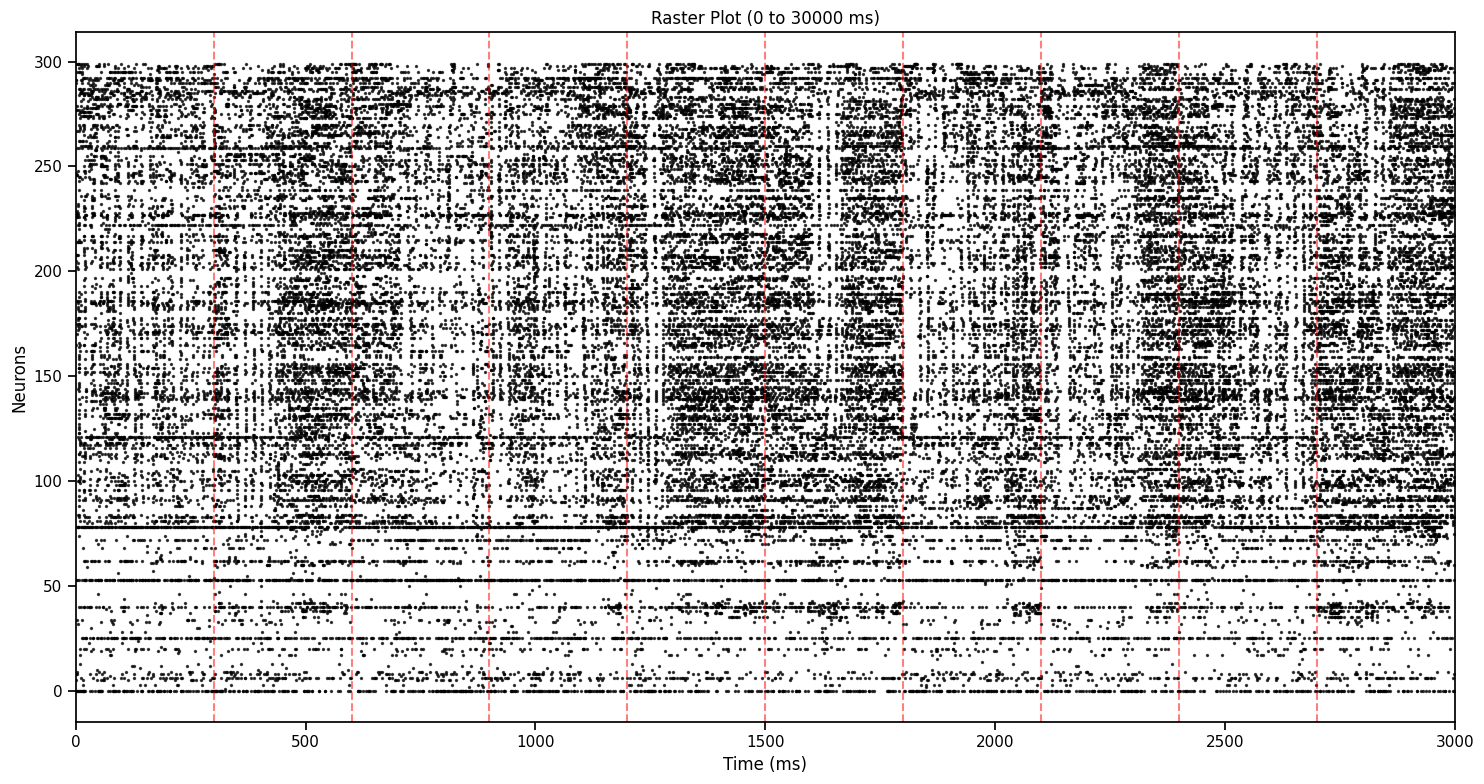

3000

In [ ]:
osc_trials = np.array([487, 478, 476, 473, 460, 462, 463, 464, 465, 466, 467, 468, 469, 470])
osc_trials =  np.array([407, 408, 411]) #, 434, 454, 457, 463, 467, 468, 469, 553, 546, 540, 538, 537, 533, ])
osc_trials =  np.array([407, 408, 411 , 434, 454, 457, 463, 467, 468, 469, 553, 546, 540, 538, 537, 533, ])

# Extract selected trials
flat_data_selected, selected_labels, selected_indices = select_trials_from_flat_data(
    flat_data,
    trial_labels,
    osc_trials,
    n_bins_per_trial
)

fig = plot_raster_from_flat_data(
    flat_data_selected[600:900],
    n_bins_per_trial,
    bin_ms=10,
    time_window_ms=[-500, 2000],
    start_bin=0,  # Start at 500ms
    end_bin=3000     # End at 1000ms
)
plt.show()

len(flat_data_selected[0])


## PPSEQ Fit / Intial Viz

FITTING PP-SEQ MODEL
Configuring PP-Seq with 4 sequence templates...
PP-Seq Configuration:
  num_templates: 4
  template_duration: 10
  alpha_a0: 2.5
  beta_a0: 0.2
  alpha_b0: 1
  beta_b0: 0.1
  alpha_t0: 0.1
  beta_t0: 0.1

Fitting PP-Seq model...
Training PP-Seq (this may take a few minutes)...


✓ PP-Seq training complete!


tensor(0.0648, device='cuda:0')

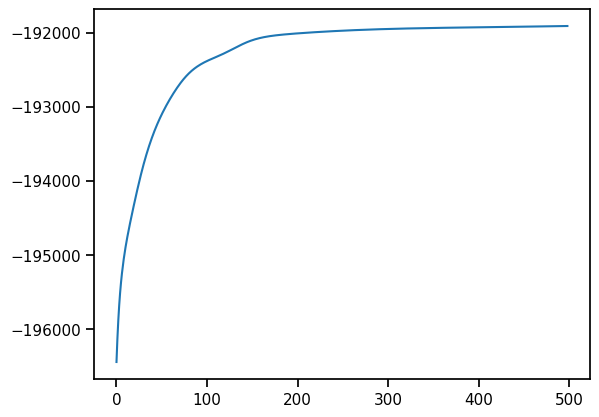

In [ ]:
#%% PP-Seq Model Configuration and Training
import importlib
import ppseq.model
importlib.reload(ppseq.model)
from ppseq.model import PPSeq

def configure_and_fit_ppseq(flat_data, num_templates=12):
    """
    Configure and fit PP-Seq model following analysis plan parameters:
    - Sequence types R = 10-20 (using 12 as middle ground)
    - NO time warping (standard PP-Seq)
    - Region-specific background rates
    """
    print(f"Configuring PP-Seq with {num_templates} sequence templates...")
    n_neurons = len(flat_data)
    # Convert to torch tensor
    torch_data = torch.from_numpy(flat_data).float().to('cuda')

    # Configure PP-Seq model parameters (following analysis plan)
    ppseq_config = {
    'num_templates': num_templates,           # Start with fewer
    'template_duration': 30,      # Keep this
    'alpha_a0': 7.0,             # Higher expected amplitude
    'beta_a0': 0.2,
    'alpha_b0': 1,            # Much lower background
    'beta_b0': 0.1,             #  low background rate
    'alpha_t0': 2,             # Moderate template flexibility
    'beta_t0': 0.2
}
    ppseq_config = {
    'num_templates': num_templates,
    'template_duration': 10,
    'alpha_a0': 2.5,
    'beta_a0': 0.2,
    'alpha_b0': 1,
    'beta_b0': 0.1,
    'alpha_t0': .1,
    'beta_t0': 0.1
}

    print("PP-Seq Configuration:")
    for key, value in ppseq_config.items():
        print(f"  {key}: {value}")

    # Create and fit PP-Seq model
    print("\nFitting PP-Seq model...")
    model = PPSeq(
        num_neurons=n_neurons,
        device=device,
        **ppseq_config,

    )

    # Fit model (this may take several minutes for large datasets)
    print("Training PP-Seq (this may take a few minutes)...")
    log_likelihoods, amplitudes = model.fit(torch_data, num_iter=500)

    print("✓ PP-Seq training complete!")
    # print(f"Final log-likelihood: {log_likelihoods[-1]:.2f}")

    return model, amplitudes, log_likelihoods, torch_data

# Fit PP-Seq model
print("="*50)
print("FITTING PP-SEQ MODEL")
print("="*50)



model, amplitudes, log_likelihoods, torch_data = configure_and_fit_ppseq(
    flat_data_selected[600:900, 0:3000],
    num_templates=4
)





plt.plot(log_likelihoods.cpu().numpy()[1:])

torch.mean(torch_data)

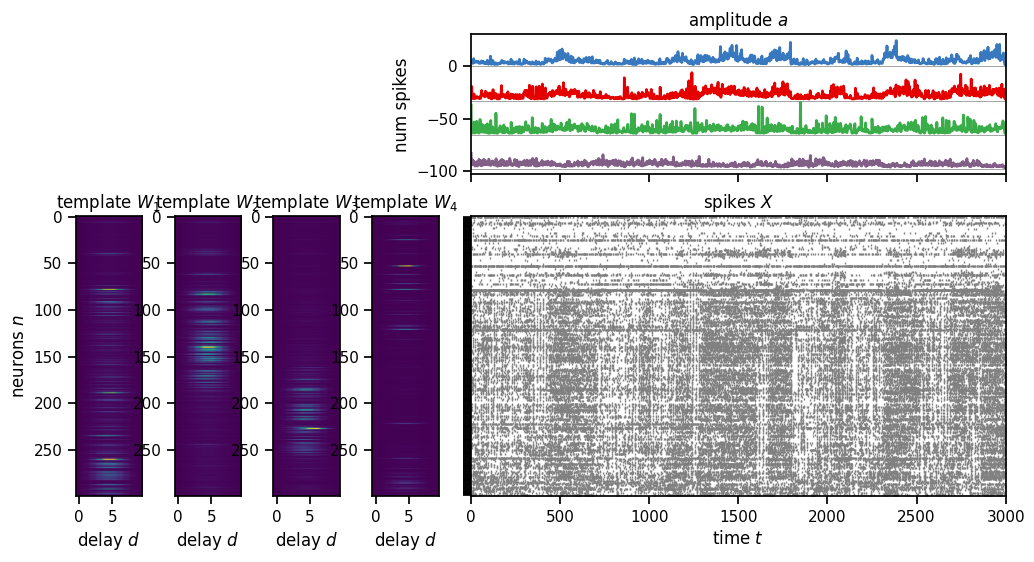

In [ ]:
fig_model = plot_model(model.templates.cpu(), amplitudes.cpu(), torch_data.cpu())

## PPSEQ VIZ

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt


def plot_ppseq_raster_sorted_by_templates(data, model, amplitudes, start=0, end=200, show_activation=True):
    """
    PP-Seq raster plot sorted by template membership and timing within template.
    Optimized version with vectorized operations instead of loops.

    Args:
        data: torch tensor (neurons, time)
        model: fitted PPSeq model
        amplitudes: amplitude tensor from model fit
        start, end: time window to plot
        show_activation: bool, whether to show template activation subplot
    """
    # Extract subset
    data_subset = data[:, start:end]
    amp_subset = amplitudes[:, start:end]

    # Get model parameters
    base_rates = model.base_rates.cpu()
    templates = model.templates.cpu()
    template_offsets = model.template_offsets.cpu()

    N, T = data_subset.shape
    K = templates.shape[0]  # number of templates
    D = templates.shape[2]  # template duration

    # Calculate which template is most active for each neuron at each time point
    template_contributions = torch.zeros(K, N, T)

    for k in range(K):
        # Convolve amplitude with flipped template
        conv_result = F.conv1d(
            amp_subset[[k], :],
            torch.flip(templates[[k]].permute(1, 0, 2), [2]),
            padding=D-1
        )[:, :-D+1]
        template_contributions[k] = conv_result

    # Add background
    background = base_rates.view(N, 1).expand(N, T)
    all_contributions = torch.cat([background.unsqueeze(0), template_contributions])

    # VECTORIZED: Find most responsible template for each spike
    spike_colors = torch.full_like(data_subset, -1, dtype=torch.long)  # -1 = no spike

    # Find all spike positions
    spike_rows, spike_cols = torch.where(data_subset > 0)

    # For each spike, get the template with max contribution
    if len(spike_rows) > 0:  # Only process if there are spikes
        max_contributors = torch.argmax(all_contributions[:, spike_rows, spike_cols], dim=0)
        spike_colors[spike_rows, spike_cols] = max_contributors

    # VECTORIZED: Calculate template strength for each neuron
    neuron_template_strength = torch.zeros(N, K+1)

    # For each template, count occurrences across all time points
    for k in range(K+1):
        neuron_template_strength[:, k] = torch.sum(spike_colors == k, dim=1).float()

    # Get primary template for each neuron
    primary_templates = torch.argmax(neuron_template_strength, dim=1)

    # Create sorting info: (neuron_idx, primary_template, timing_within_template)
    neuron_sort_info = []
    for n in range(N):
        primary_template = primary_templates[n].item()

        if primary_template == 0:  # Background
            timing = 0  # Background neurons don't have timing
        else:
            # Get the timing offset for this neuron in its primary template
            timing = template_offsets[primary_template - 1, n].item()

        neuron_sort_info.append((n, primary_template, timing))

    # Sort by: 1) primary template, 2) timing within template
    neuron_sort_info.sort(key=lambda x: (x[1], x[2]))

    # Extract sorted neuron indices
    sorted_indices = torch.tensor([info[0] for info in neuron_sort_info])
    sorted_spike_colors = spike_colors[sorted_indices, :]

    # Create the plot - single or double subplot
    if show_activation:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12),
                                       gridspec_kw={'height_ratios': [3, 1]})
    else:
        fig, ax1 = plt.subplots(figsize=(14, 10))

    # Color scheme: background=gray, templates=colors
    colors = ['gray', 'red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'cyan', 'yellow']

    # UPPER PLOT: Raster plot
    # Plot spikes colored by template
    for color_idx in range(min(K+1, len(colors))):
        spike_coords = torch.where(sorted_spike_colors == color_idx)
        if len(spike_coords[0]) > 0:
            label = 'Background' if color_idx == 0 else f'Template {color_idx}'
            ax1.scatter(spike_coords[1].numpy(), spike_coords[0].numpy(),
                       c=colors[color_idx], s=10, alpha=0.8, label=label)

    # Add template boundaries and labels
    current_template = neuron_sort_info[0][1]  # Template of first neuron
    boundaries = [0]  # Start with 0
    template_info = []  # (template_id, start_idx, end_idx)

    for i in range(1, len(neuron_sort_info)):
        if neuron_sort_info[i][1] != current_template:
            # End current template group
            template_info.append((current_template, boundaries[-1], i))
            boundaries.append(i)
            current_template = neuron_sort_info[i][1]

    # Add final template
    template_info.append((current_template, boundaries[-1], len(neuron_sort_info)))

    # Draw boundaries (skip the first one at 0)
    for boundary in boundaries[1:]:
        ax1.axhline(y=boundary, color='black', linewidth=1.5, alpha=0.7, linestyle='--')

    # Add template labels on the right
    for template_idx, start_y, end_y in template_info:
        y_pos = (start_y + end_y) / 2  # Middle of the template group

        if template_idx == 0:
            label_text = 'BG'  # Background
        else:
            label_text = f'T{template_idx}'

        ax1.text(T + 10, y_pos, label_text, ha='left', va='center',
               fontsize=12, fontweight='bold',
               bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[template_idx], alpha=0.3))

    # Set labels and title for raster plot
    if show_activation:
        ax1.set_ylabel('Neuron (sorted by template & timing)')
        ax1.set_title('PP-Seq Raster: Sorted by Template Assignment & Timing\n(Earlier firing neurons lower on y-axis)')
    else:
        ax1.set_xlabel(f'Time (bins from {start} to {end})')
        ax1.set_ylabel('Neuron (sorted by template & timing)')
        ax1.set_title('PP-Seq Raster: Sorted by Template Assignment & Timing\n(Earlier firing neurons lower on y-axis)')

    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.set_xlim(0, T)

    # LOWER PLOT: Template activation over time (if requested)
    if show_activation:
        time_bins = np.arange(T)

        # Plot each template's activation
        for k in range(K):
            template_activation = amp_subset[k, :].numpy()
            ax2.plot(time_bins, template_activation,
                    color=colors[k+1], linewidth=2,
                    label=f'Template {k+1}', alpha=0.8)

        # Add background activation (sum of background firing rates)
        background_activation = base_rates.sum().item() * np.ones(T)
        ax2.plot(time_bins, background_activation,
                color=colors[0], linewidth=2,
                label='Background', alpha=0.8, linestyle='--')

        ax2.set_xlabel(f'Time (bins from {start} to {end})')
        ax2.set_ylabel('Template Activation')
        ax2.set_title('Template Activation Over Time')
        # ax2.legend()
        # ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, T)

        # Print diagnostic info
        total_spikes = torch.sum(data_subset > 0).item()
        background_spikes = torch.sum(spike_colors == 0).item()
        sequence_spikes = total_spikes - background_spikes

        print(f"Spike Classification:")
        print(f"  Background: {background_spikes:,} ({background_spikes/total_spikes:.1%})")
        print(f"  Sequences:  {sequence_spikes:,} ({sequence_spikes/total_spikes:.1%})")
        print(f"  Total:      {total_spikes:,}")

        # Template activation summary
        print(f"\nTemplate Activation Summary:")
        for k in range(K):
            max_amp = torch.max(amp_subset[k, :]).item()
            mean_amp = torch.mean(amp_subset[k, :]).item()
            print(f"  Template {k+1}: max={max_amp:.2f}, mean={mean_amp:.2f}")

    plt.tight_layout()
    return fig

# Usage:
# fig = plot_ppseq_raster_sorted_by_templates(
#     torch_data.cpu(),
#     model,
#     amplitudes.cpu(),
#     start=1000,
#     end=2000,
#     show_activation=True  # Set to False for raster only
# )
# plt.show()

Window-based Classification (thresh=14.0, win=±5):
  Sequence windows: 264 bins (26.4% of time)
  Detected peaks: 26
  Background spikes: 13,356 (69.8%)
  Sequence spikes:   5,774 (30.2%)
  Total spikes:      19,130


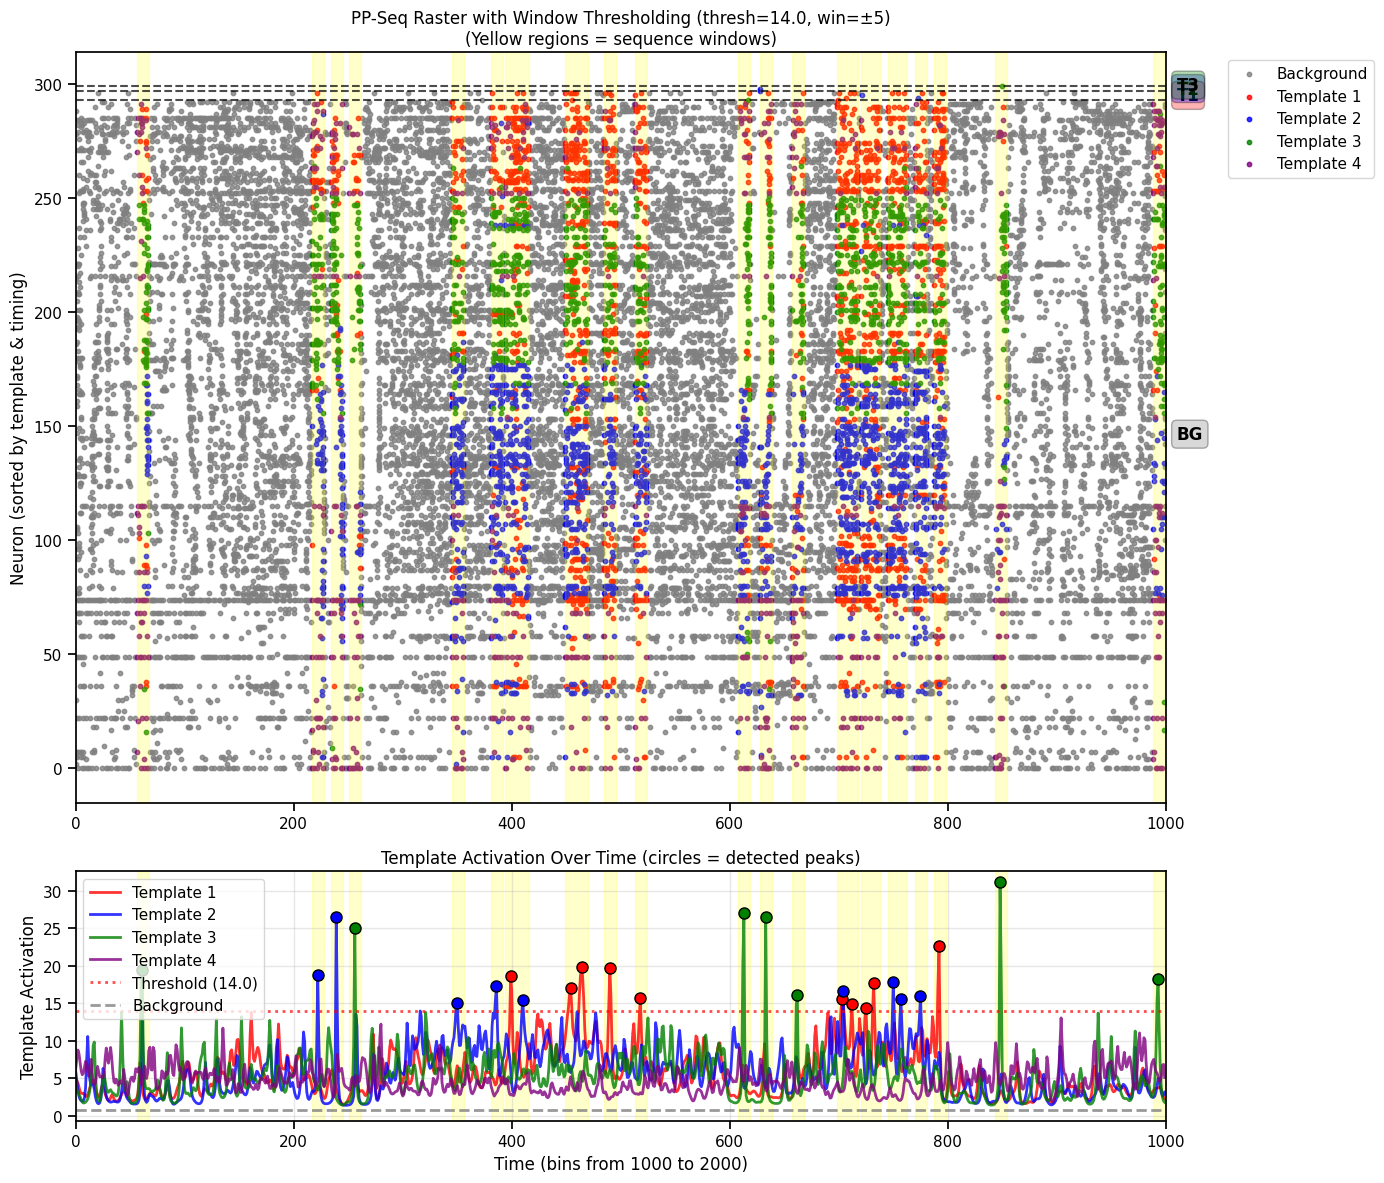

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


def plot_ppseq_raster_with_windows(data, model, amplitudes, start=0, end=200,
                                 activation_threshold=15.0, window_half_size=5,
                                 show_activation=True):
    """
    PP-Seq raster plot with window-based thresholding around activation peaks.
    Only assigns spikes to templates within windows around high activation periods.

    Args:
        data: torch tensor (neurons, time)
        model: fitted PPSeq model
        amplitudes: amplitude tensor from model fit
        start, end: time window to plot
        activation_threshold: minimum template activation to trigger sequence window
        window_half_size: bins around peak (total window = 2*window_half_size + 1)
        show_activation: bool, whether to show template activation subplot
    """
    # Extract subset
    data_subset = data[:, start:end]
    amp_subset = amplitudes[:, start:end]

    # Get model parameters
    base_rates = model.base_rates.cpu()
    templates = model.templates.cpu()
    template_offsets = model.template_offsets.cpu()

    N, T = data_subset.shape
    K = templates.shape[0]  # number of templates
    D = templates.shape[2]  # template duration

    # Calculate template contributions
    template_contributions = torch.zeros(K, N, T)

    for k in range(K):
        # Convolve amplitude with flipped template
        conv_result = F.conv1d(
            amp_subset[[k], :],
            torch.flip(templates[[k]].permute(1, 0, 2), [2]),
            padding=D-1
        )[:, :-D+1]
        template_contributions[k] = conv_result

    # Add background
    background = base_rates.view(N, 1).expand(N, T)
    all_contributions = torch.cat([background.unsqueeze(0), template_contributions])

    # FIND SEQUENCE WINDOWS: where template activation exceeds threshold
    sequence_mask = torch.zeros(T, dtype=torch.bool)
    peak_info = []  # Store (template_idx, peak_time, peak_value) for visualization

    for k in range(K):
        template_activation = amp_subset[k, :].numpy()

        # Find peaks above threshold
        peaks, properties = find_peaks(template_activation, height=activation_threshold, distance=window_half_size)

        for peak_idx in peaks:
            # Define window around peak
            window_start = max(0, peak_idx - window_half_size)
            window_end = min(T, peak_idx + window_half_size + 1)

            # Mark this window for sequence assignment
            sequence_mask[window_start:window_end] = True

            # Store peak info
            peak_info.append((k + 1, peak_idx, template_activation[peak_idx]))  # k+1 for 1-based template numbering

    # ASSIGN SPIKES: winner-take-all within sequence windows, background elsewhere
    spike_colors = torch.full_like(data_subset, -1, dtype=torch.long)  # -1 = no spike

    # Find all spike positions
    spike_rows, spike_cols = torch.where(data_subset > 0)

    if len(spike_rows) > 0:  # Only process if there are spikes
        # Check which spikes fall within sequence windows
        in_sequence_window = sequence_mask[spike_cols]

        # For spikes in sequence windows: do winner-take-all assignment
        seq_spike_rows = spike_rows[in_sequence_window]
        seq_spike_cols = spike_cols[in_sequence_window]

        if len(seq_spike_rows) > 0:
            seq_contributions = all_contributions[:, seq_spike_rows, seq_spike_cols]
            max_contributors = torch.argmax(seq_contributions, dim=0)
            spike_colors[seq_spike_rows, seq_spike_cols] = max_contributors

        # For spikes outside sequence windows: assign to background
        bg_spike_rows = spike_rows[~in_sequence_window]
        bg_spike_cols = spike_cols[~in_sequence_window]
        spike_colors[bg_spike_rows, bg_spike_cols] = 0  # Background

    # VECTORIZED: Calculate template strength for each neuron
    neuron_template_strength = torch.zeros(N, K+1)

    # For each template, count occurrences across all time points
    for k in range(K+1):
        neuron_template_strength[:, k] = torch.sum(spike_colors == k, dim=1).float()

    # Get primary template for each neuron
    primary_templates = torch.argmax(neuron_template_strength, dim=1)

    # Create sorting info: (neuron_idx, primary_template, timing_within_template)
    neuron_sort_info = []
    for n in range(N):
        primary_template = primary_templates[n].item()

        if primary_template == 0:  # Background
            timing = 0  # Background neurons don't have timing
        else:
            # Get the timing offset for this neuron in its primary template
            timing = template_offsets[primary_template - 1, n].item()

        neuron_sort_info.append((n, primary_template, timing))

    # Sort by: 1) primary template, 2) timing within template
    neuron_sort_info.sort(key=lambda x: (x[1], x[2]))

    # Extract sorted neuron indices
    sorted_indices = torch.tensor([info[0] for info in neuron_sort_info])
    sorted_spike_colors = spike_colors[sorted_indices, :]

    # Create the plot - single or double subplot
    if show_activation:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12),
                                       gridspec_kw={'height_ratios': [3, 1]})
    else:
        fig, ax1 = plt.subplots(figsize=(14, 10))

    # Color scheme: background=gray, templates=colors
    colors = ['gray', 'red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'cyan', 'yellow']

    # UPPER PLOT: Raster plot
    # Plot spikes colored by template
    for color_idx in range(min(K+1, len(colors))):
        spike_coords = torch.where(sorted_spike_colors == color_idx)
        if len(spike_coords[0]) > 0:
            label = 'Background' if color_idx == 0 else f'Template {color_idx}'
            ax1.scatter(spike_coords[1].numpy(), spike_coords[0].numpy(),
                       c=colors[color_idx], s=10, alpha=0.8, label=label)

    # Add sequence windows as vertical shaded regions
    for window_start in range(T):
        if sequence_mask[window_start] and (window_start == 0 or not sequence_mask[window_start-1]):
            # Start of a new window
            window_end = window_start
            while window_end < T and sequence_mask[window_end]:
                window_end += 1
            ax1.axvspan(window_start, window_end, alpha=0.2, color='yellow', label='Sequence Window' if window_start == 0 else "")

    # Add template boundaries and labels
    current_template = neuron_sort_info[0][1]  # Template of first neuron
    boundaries = [0]  # Start with 0
    template_info = []  # (template_id, start_idx, end_idx)

    for i in range(1, len(neuron_sort_info)):
        if neuron_sort_info[i][1] != current_template:
            # End current template group
            template_info.append((current_template, boundaries[-1], i))
            boundaries.append(i)
            current_template = neuron_sort_info[i][1]

    # Add final template
    template_info.append((current_template, boundaries[-1], len(neuron_sort_info)))

    # Draw boundaries (skip the first one at 0)
    for boundary in boundaries[1:]:
        ax1.axhline(y=boundary, color='black', linewidth=1.5, alpha=0.7, linestyle='--')

    # Add template labels on the right
    for template_idx, start_y, end_y in template_info:
        y_pos = (start_y + end_y) / 2  # Middle of the template group

        if template_idx == 0:
            label_text = 'BG'  # Background
        else:
            label_text = f'T{template_idx}'

        ax1.text(T + 10, y_pos, label_text, ha='left', va='center',
               fontsize=12, fontweight='bold',
               bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[template_idx], alpha=0.3))

    # Set labels and title for raster plot
    threshold_str = f"thresh={activation_threshold}, win=±{window_half_size}"
    if show_activation:
        ax1.set_ylabel('Neuron (sorted by template & timing)')
        ax1.set_title(f'PP-Seq Raster with Window Thresholding ({threshold_str})\n(Yellow regions = sequence windows)')
    else:
        ax1.set_xlabel(f'Time (bins from {start} to {end})')
        ax1.set_ylabel('Neuron (sorted by template & timing)')
        ax1.set_title(f'PP-Seq Raster with Window Thresholding ({threshold_str})\n(Yellow regions = sequence windows)')

    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.set_xlim(0, T)

    # LOWER PLOT: Template activation over time (if requested)
    if show_activation:
        time_bins = np.arange(T)

        # Plot each template's activation
        for k in range(K):
            template_activation = amp_subset[k, :].numpy()
            ax2.plot(time_bins, template_activation,
                    color=colors[k+1], linewidth=2,
                    label=f'Template {k+1}', alpha=0.8)

        # Add threshold line
        ax2.axhline(y=activation_threshold, color='red', linestyle=':',
                   linewidth=2, alpha=0.7, label=f'Threshold ({activation_threshold})')

        # Mark detected peaks
        for template_idx, peak_time, peak_value in peak_info:
            ax2.plot(peak_time, peak_value, 'o', color=colors[template_idx],
                    markersize=8, markeredgecolor='black', markeredgewidth=1)

        # Add sequence windows as vertical shaded regions
        for window_start in range(T):
            if sequence_mask[window_start] and (window_start == 0 or not sequence_mask[window_start-1]):
                # Start of a new window
                window_end = window_start
                while window_end < T and sequence_mask[window_end]:
                    window_end += 1
                ax2.axvspan(window_start, window_end, alpha=0.2, color='yellow')

        # Add background activation (sum of background firing rates)
        background_activation = base_rates.sum().item() * np.ones(T)
        ax2.plot(time_bins, background_activation,
                color=colors[0], linewidth=2,
                label='Background', alpha=0.8, linestyle='--')

        ax2.set_xlabel(f'Time (bins from {start} to {end})')
        ax2.set_ylabel('Template Activation')
        ax2.set_title('Template Activation Over Time (circles = detected peaks)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, T)

        # Print diagnostic info
        total_spikes = torch.sum(data_subset > 0).item()
        background_spikes = torch.sum(spike_colors == 0).item()
        sequence_spikes = total_spikes - background_spikes
        sequence_bins = torch.sum(sequence_mask).item()

        print(f"Window-based Classification ({threshold_str}):")
        print(f"  Sequence windows: {sequence_bins} bins ({sequence_bins/T:.1%} of time)")
        print(f"  Detected peaks: {len(peak_info)}")
        print(f"  Background spikes: {background_spikes:,} ({background_spikes/total_spikes:.1%})")
        print(f"  Sequence spikes:   {sequence_spikes:,} ({sequence_spikes/total_spikes:.1%})")
        print(f"  Total spikes:      {total_spikes:,}")

        # Peak summary
        # if peak_info:
        #     print(f"\nDetected Peaks:")
        #     for template_idx, peak_time, peak_value in peak_info:
        #         print(f"  Template {template_idx}: time={peak_time}, value={peak_value:.2f}")
        # else:
        #     print(f"\nNo peaks detected above threshold {activation_threshold}")

    plt.tight_layout()
    return fig

# Usage examples:

# Default: threshold=15, window=±5 bins
fig1 = plot_ppseq_raster_with_windows(
    torch_data.cpu(), model, amplitudes.cpu(),
    start=1000, end=2000,
    activation_threshold=14.0, window_half_size=5,
    show_activation=True
)
plt.show()


plt.show()

## PPSEQ Update?

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as dist

from fastprogress import progress_bar
from torch import Tensor
from jaxtyping import Float


class GLMPPSeq:
    """PPSeq is a probabilistic model for detecting sequences of spikes
    embedded in multi-neuronal spike trains. It is based on a Poisson
    latent variable model, akin to a non-negative, convolutional matrix
    factorization.
    """
    base_rates : Float[Tensor, "num_neurons"]
    template_scales: Float[Tensor, "num_templates num_neurons"]
    template_offsets: Float[Tensor, "num_templates num_neurons"]
    template_widths: Float[Tensor, "num_templates num_neurons"]

    def __init__(self,
                 num_templates: int,
                 num_neurons: int,
                 template_duration: int,
                 alpha_a0: float=0.,
                 beta_a0: float=0.,
                 alpha_b0: float=0.,
                 beta_b0: float=0.,
                 alpha_t0: float=0.,
                 beta_t0: float=0.,
                 device=None
                 ):
        self.num_templates = num_templates
        self.num_neurons = num_neurons
        self.template_duration = template_duration

        # Set the device
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            if not torch.cuda.is_available():
                print('Could not find a GPU. Defaulting to CPU instead.')
        self.device = device


        self.base_rates = torch.ones(num_neurons, device=device)
        self.template_scales = torch.ones(num_templates, num_neurons, device=device) / num_neurons
        self.template_offsets = template_duration * torch.rand(num_templates, num_neurons, device=device)
        self.template_widths = torch.ones(self.num_templates, self.num_neurons, device=device)

        covariate_dim = 5
        self.beta = torch.zeros(num_neurons, covariate_dim + 1, device=device)

        # Set prior hyperparameters
        self.alpha_a0 = alpha_a0
        self.beta_a0 = beta_a0
        self.alpha_b0 = alpha_b0
        self.beta_b0 = beta_b0
        self.alpha_t0 = alpha_t0
        self.beta_t0 = beta_t0

    @property
    def templates(self) -> Float[Tensor, "num_templates num_neurons duration"]:
        """Compute the templates from the mean, std, and amplitude of the Gaussian kernel.
        """
        D = self.template_duration
        amp, mu, sigma = self.template_scales, self.template_offsets, self.template_widths
        ds = torch.arange(D, device=self.device)[:, None, None]
        p = dist.Normal(mu, sigma)
        W = p.log_prob(ds).exp().permute(1,2,0)
        return W / W.sum(dim=2, keepdim=True) * amp[:, :, None]

    def get_background_rates(self, X=None):
      """
      Returns background rates: either constant or time-varying via GLM
      X: (covariate_dim, num_timesteps) covariates
      """

      # Add intercept to covariates
      T = X.shape[1]
      X_with_intercept = torch.cat([torch.ones(1, T, device=X.device), X], dim=0)

      # Compute GLM predictions: exp(beta^T * X)
      eta = torch.matmul(self.beta, X_with_intercept)  # (N, T)
      return torch.exp(eta)  # (N, T)

    def reconstruct(self,
                    amplitudes: Float[Tensor, "num_templates num_timesteps"]) \
                    -> Float[Tensor, "num_neurons num_timesteps"]:
        """
        Reconstruct the firing rate given the model parameters and latent variables.

        Parameters
        ----------
        amplitudes: the amplitudes for each template as a function of time
        """
        D = self.template_duration
        kernel = torch.flip(self.templates.permute(1,0,2), [2])
        background = self.get_background_rates(X)
        return background + F.conv1d(amplitudes, kernel, padding=D-1)[:,:-D+1]

    def log_likelihood(self,
                       data: Float[Tensor, "num_neurons num_timesteps"],
                       amplitudes: Float[Tensor, "num_templates num_timesteps"],
                       rows = None,
                       cols = None) -> float:
        """
        Calculate the log probability given data X
        and estimated parameters a, b, W

        Parameters
        ----------
        data: spike count matrix
        amplitudes: amplitudes of each template over time
        rows,cols: torch.tensor([list of row/col indices]) that represent a subset of rows * cols where the log likelihood is calculated

        Returns
        -------
        Scalar log probability
        """
        D = self.template_duration
        kernel = torch.flip(self.templates.permute(1,0,2),[2])
        rates = self.base_rates[:, None] + F.conv1d(amplitudes, kernel, padding=D-1)[:,:-D+1]
        rates = torch.clamp(rates, min=1e-7)
        if rows is None or cols is None:
            return torch.sum(dist.Poisson(rates).log_prob(data))

        data_selected = data[rows,:][:,cols]
        rates_selected = rates[rows,:][:,cols]
        poisson_dist = dist.Poisson(rates_selected)
        log_probs = poisson_dist.log_prob(data_selected)
        log_likelihood = torch.sum(log_probs)
        return log_likelihood


    def _update_amplitudes(self, data, amplitudes):
        D, T = self.template_duration, data.shape[1]
        b, W = self.base_rates, self.templates
        kernel = torch.flip(W.permute(1,0,2), [2])
        rates = b[:, None] + F.conv1d(amplitudes, kernel, padding=D-1)[:,:-D+1]
        ratio = data / (rates + 1e-7)

        alpha_post = amplitudes * F.conv1d(ratio, W, padding=D-1)[:,D-1:] + self.alpha_a0
        beta_post = torch.sum(W, dim=(1,2)).unsqueeze(1).repeat(1,T) + self.beta_a0
        return torch.clip((alpha_post - 1) / beta_post, 0)

    def create_smooth_covariates(self, data):
      """Create smooth temporal features using Gaussian filtering"""
      N, T = data.shape
      pop_rate = data.mean(dim=0)  # (T,)

      # Create multiple timescales of smoothing
      sigmas = [10, 25, 50, 100, 200]  # Different smoothing windows
      X = []

      for sigma in sigmas:
          # Create Gaussian kernel
          kernel_size = int(4 * sigma) + 1
          x = torch.arange(kernel_size, dtype=torch.float32, device=data.device) - kernel_size // 2
          kernel = torch.exp(-x**2 / (2 * sigma**2))
          kernel = kernel / kernel.sum()

          # Smooth the population rate
          smoothed = F.conv1d(
              pop_rate.unsqueeze(0).unsqueeze(0),
              kernel.unsqueeze(0).unsqueeze(0),
              padding=kernel_size//2
          ).squeeze()

          X.append(smoothed)

      return torch.stack(X)  # (5, T)

    def _update_base_rates(self, data, amplitudes, max_iter=10, tol=1e-4):
      """
      Vectorized Newton-Raphson update for GLM parameters
      Updates all neurons simultaneously for speed
      """
      D = self.template_duration
      T = data.shape[1]
      N = self.num_neurons

      # Create smooth temporal covariates - consider using RBF basis functions
      X = self.create_smooth_covariates(data)
      X_with_intercept = torch.cat([torch.ones(1, T, device=X.device), X], dim=0)  # (P+1, T)

      # expected background
      W = self.templates
      kernel = torch.flip(W.permute(1,0,2), [2])
      seq_rates = F.conv1d(amplitudes, kernel, padding=D-1)[:,:-D+1]

      #  total rates
      # NOTE: probably shouldnt be using Beta to get background rates
      background = self.get_background_rates(X)
      total_rates = background + seq_rates

      # resid. ratio
      # X_n,t / lambda_nt - WHY DO WE NEED THIS?
      ratio = data / (total_rates + 1e-7)
      expected_background = ratio * background  # E[z_{n,t,0}], shape: (N, T)

      # newton updates
      for iter in range(max_iter):
          # Current predictions for all neurons
          eta = torch.matmul(self.beta, X_with_intercept)  # (N, T)
          mu = torch.exp(eta)  # (N, T)

          # Gradient for all neurons: ∇L = X * (y - μ)
          # should residuals be - X - E[z_{n,t,0}] or X - e^(B^Tx) (yes or no - determines whetehr residuals is X-EB or X-mu)
          # note that this is EM on coordinated ascent VI not vanilla GLM M step
          residuals = expected_background - mu  # (N, T)
          # should be ^ X - **something**
          gradient = torch.matmul(residuals, X_with_intercept.T)  # (N, P+1)

          # Diagonal Fisher Information approximation
          # For Poisson: Fisher = X * diag(μ) * X^T
          # We approximate with diagonal: Fisher_diag = Σ_t μ_{n,t} * x_t^2
          fisher_diag = torch.matmul(mu, (X_with_intercept.T)**2)  # (N, P+1)

          # Newton step with diagonal approximation
          # β_new = β_old + Fisher^(-1) * gradient
          delta = gradient / (fisher_diag + 1e-4)  # Add regularization for stability
          # Update all betas simultaneously
          self.beta = self.beta + delta

          """
          we couldve done SGD
          or first order updates
          self.beta += delta * gradient

          or second order as done above
          """

          # Check convergence (using Frobenius norm for matrix)
          if torch.norm(delta) < tol:
              break


    def _update_templates(self,
                          data,
                          amplitudes):

        D = self.template_duration
        b, W = self.base_rates, self.templates
        kernel = torch.flip(W.permute(1,0,2), [2])
        rates = b[:, None] + F.conv1d(amplitudes, kernel, padding=D-1)[:,:-D+1]
        ratio = data / (rates + 1e-7)

        alpha_post = self.alpha_t0 + W * torch.flip(
            F.conv1d(amplitudes.unsqueeze(1),
                     ratio.unsqueeze(1),
                     padding=D-1)[:,:,:-D+1], [2])
        beta_post = self.beta_t0 + torch.sum(amplitudes, dim=1)[:,None,None]
        # targets = torch.clip((alpha_post - 1) / (beta_post), 1e-4)
        targets = torch.clip((alpha_post) / (beta_post), 1e-4)
        norm_targets = targets / torch.clip(targets.sum(dim=2, keepdim=True), 1e-4) # ensure no division by zero

        # Estimate the Gaussian template parameters by matching moments
        ds = torch.arange(self.template_duration, device=self.device)
        scales = targets.sum(dim=2) # (K,N)
        delays = torch.sum(ds * norm_targets, dim=2) # (K,N)
        widths = torch.sqrt(torch.sum((ds - delays[:, :, None])**2 * norm_targets, dim=2)) + 1e-4
        assert torch.all(torch.isfinite(scales))
        assert torch.all(torch.isfinite(delays))
        assert torch.all(torch.isfinite(widths))

        # Make the model identifiable by constraining the scales to sum to one across neurons
        scales /= scales.sum(axis=1, keepdim=True)
        self.template_scales = scales
        self.template_offsets = delays
        self.template_widths = widths

    def initialize_random(self,
                          data: Float[Tensor, "num_neurons num_timesteps"],
                          sequence_frac: float=0.5,
                          concentration: float=10.) \
                          -> None:
        """Initialize the model parameters randomly, while matching gross
        statistics of the data.

        Parameters
        ----------
        data: neurons x time array of spike counts
        sequence_frac: what fraction of spikes are due to sequences rather than background
        """
        K, N, D = self.num_templates, self.num_neurons, self.template_duration
        T = data.shape[1]
        avg_rate = data.mean(dim=1)
        self.base_rates = avg_rate * (1 - sequence_frac)
        self.template_scales = dist.Dirichlet(torch.clip(concentration * avg_rate, 1e-7)).sample(sample_shape=(K,))
        self.template_offsets = D * torch.rand(K, N, device=self.device)
        self.template_widths = torch.ones(K, N, device=self.device)

        # expected num spikes = .8 * total num spikes
        # unit amplitude produces 1 spike in expectation
        # need amplitudes.sum() = .2 * total num spikes
        amplitudes = dist.Dirichlet(0.1 * torch.ones(K, T, device=self.device)
        ).sample()
        amplitudes *= sequence_frac * data.sum() / K
        return amplitudes

    def initialize_default(self,
                          data: Float[Tensor, "num_neurons num_timesteps"],
                          sequence_frac: float=0.5,
                          concentration: float=10.) \
                          -> None:
        """Initialize the model parameters randomly, while matching gross
        statistics of the data.

        Parameters
        ----------
        data: neurons x time array of spike counts
        sequence_frac: what fraction of spikes are due to sequences rather than background
        """
        K, N, D = self.num_templates, self.num_neurons, self.template_duration
        T = data.shape[1]
        avg_rate = data.mean(dim=1)
        self.base_rates = avg_rate * (1 - sequence_frac)
        self.template_scales = dist.Dirichlet(torch.clip(concentration * avg_rate, 1e-7)).sample(sample_shape=(K,))
        self.template_offsets = D * torch.rand(K, N, device=self.device)
        self.template_widths = torch.ones(K, N, device=self.device)

        # expected num spikes = .8 * total num spikes
        # unit amplitude produces 1 spike in expectation
        # need amplitudes.sum() = .2 * total num spikes
        data = data.to(self.device)
        amplitudes = torch.clamp(data.sum(dim=0) + torch.normal(
            mean=sequence_frac * data.sum() / K,
            std=data.std(), size=(K, T)).to(self.device), min=1e-7)
        amplitudes /= amplitudes.sum()
        amplitudes *= sequence_frac * data.sum() / K
        return amplitudes

    def initialize_none(self, data):
        """
        Don't change the templates and base rates.
        Initialize the amplitudes to zeros.
        """
        K = self.num_templates
        T = data.shape[1]

        # amplitudes = torch.ones((K, T))
        amplitudes = dist.Uniform(0, 1).sample((K, T))
        return amplitudes

    def fit(self,
            data: Float[Tensor, "num_neurons num_timesteps"],
            num_iter: int=50,
            initialization='default',
            fit_templates=True,
            fit_base_rates=True,
            ):
        """
        Fit the model with expectation-maximization (EM).
        """
        K = self.num_templates
        T = data.shape[1]

        init_method = dict(
            random=self.initialize_random,
            default=self.initialize_default,
            none=self.initialize_none,
            )[initialization.lower()]
        amplitudes = init_method(data)


        # Run EM
        lps = []
        for _ in progress_bar(range(num_iter)):
            amplitudes = self._update_amplitudes(data, amplitudes)
            if fit_base_rates: self._update_base_rates(data, amplitudes)
            if fit_templates: self._update_templates(data, amplitudes)
            lps.append(self.log_likelihood(data, amplitudes))

        lps = torch.stack(lps) if num_iter > 0 else torch.tensor([])
        return lps, amplitudes




In [ ]:
n_neurons = len(flat_data)
# Convert to torch tensor
torch_data = torch.from_numpy(flat_data).float().to('cuda')
torch_data = torch_data[:, 2000:4000]
ppseq_config = {
    'num_templates': 5,
    'template_duration': 10,
    'alpha_a0': 2.5,
    'beta_a0': 0.2,
    'alpha_b0': 1,
    'beta_b0': 0.1,
    'alpha_t0': .1,
    'beta_t0': 0.1
}

model = GLMPPSeq(
        num_neurons=n_neurons,
        device=device,
        **ppseq_config)

# Fit model (this may take several minutes for large datasets)
print("Training PP-Seq (this may take a few minutes)...")
log_likelihoods, amplitudes = model.fit(torch_data, num_iter=500)

Training PP-Seq (this may take a few minutes)...


Spike Classification:
  Background: 188,738 (99.4%)
  Sequences:  1,151 (0.6%)
  Total:      189,889

Template Activation Summary:
  Template 1: max=11.70, mean=5.32
  Template 2: max=11.70, mean=5.32
  Template 3: max=11.70, mean=5.32
  Template 4: max=11.70, mean=5.32
  Template 5: max=11.70, mean=5.32


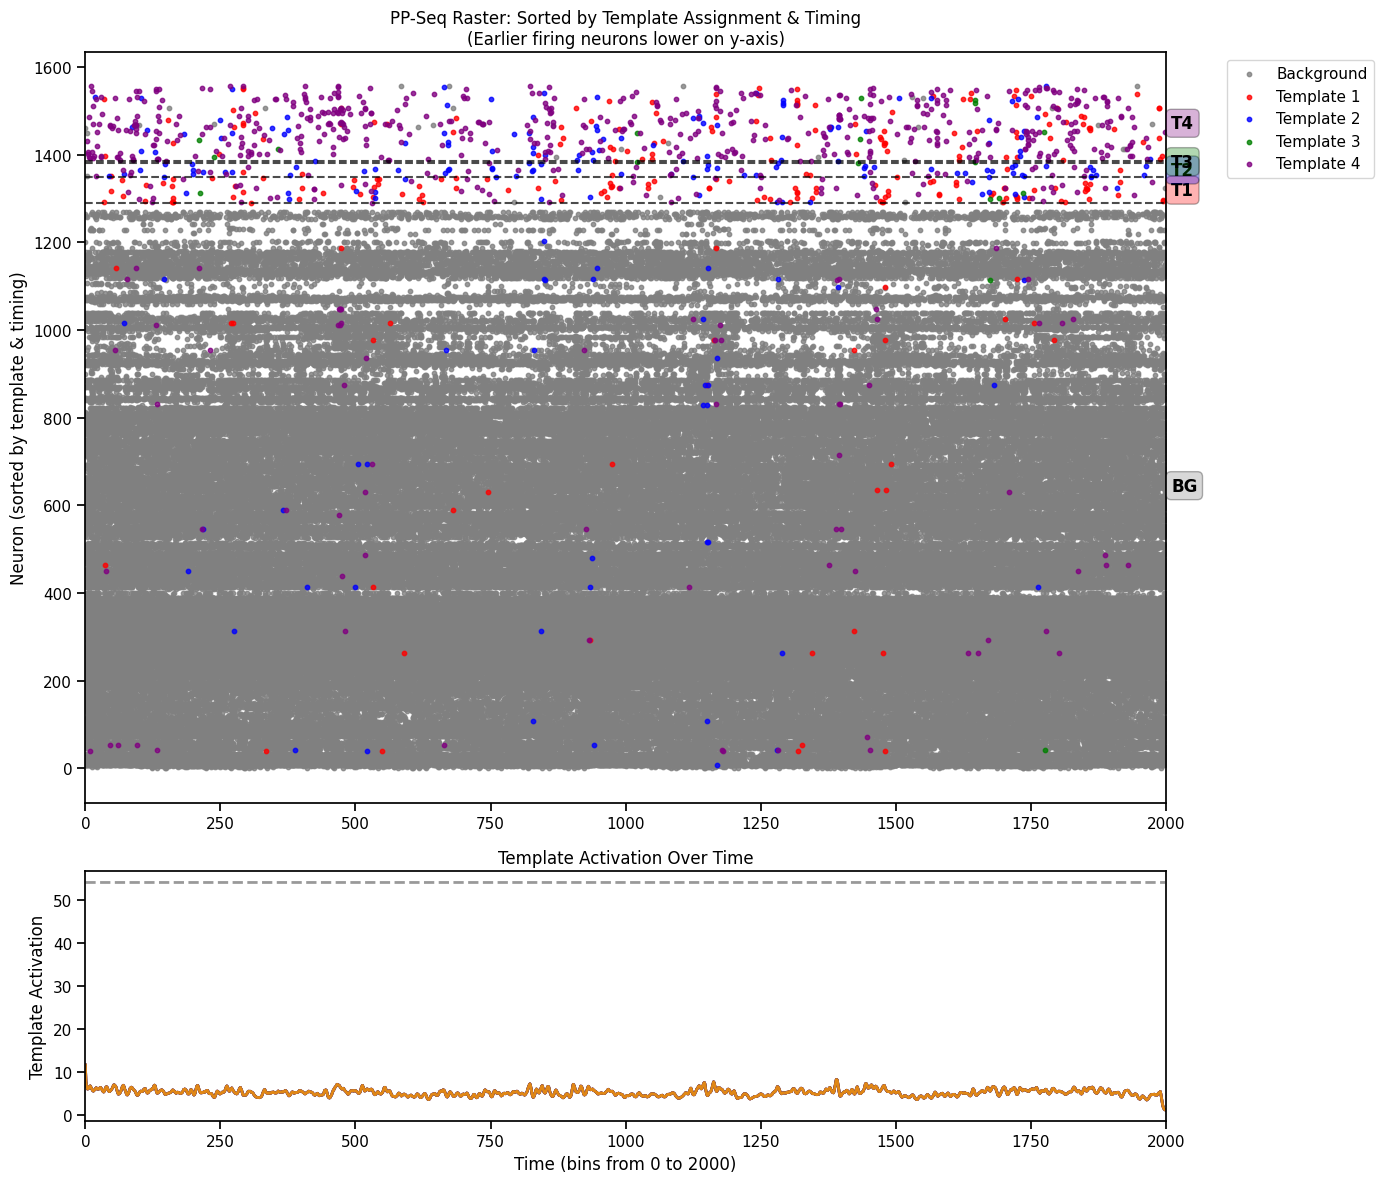

In [ ]:
fig = plot_ppseq_raster_sorted_by_templates(
    torch_data.cpu(),
    model,
    amplitudes.cpu(),
    start=0,
    end=2000,
    show_activation=True  # Set to False for raster only
)
plt.show()

In [ ]:
# import torch

# # # Get current memory usage
# print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
# print(f"Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
# print(f"Free in reserved: {(torch.cuda.memory_reserved(0) - torch.cuda.memory_allocated(0)) / 1024**3:.2f} GB")

# # Get max memory ever allocated
# print(f"Max allocated: {torch.cuda.max_memory_allocated(0) / 1024**3:.2f} GB")

# # Summary of memory
# print(torch.cuda.memory_summary(0, abbreviated=False))

# # Clear cache to free up memory
# torch.cuda.empty_cache()

# # Delete variables and clear cache
# del amplitudes, data  # Delete any large tensors you don't need
# torch.cuda.empty_cache()

# # Force garbage collection
# import gc
# gc.collect()
# torch.cuda.empty_cache()

## Brute force sequence search

In [ ]:
neural_subset - neural_subset.mean(axis=1, keepdims=True)

ValueError: operands could not be broadcast together with shapes (250,3000) (250,) 

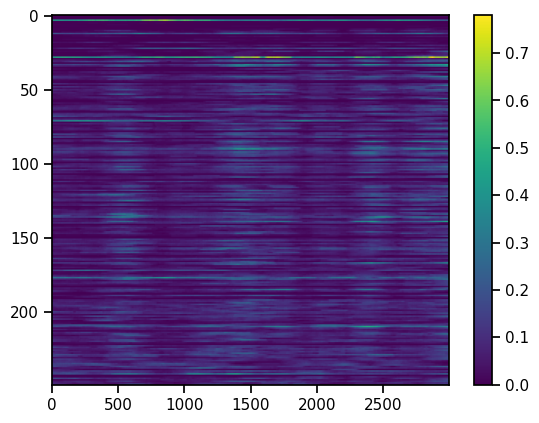

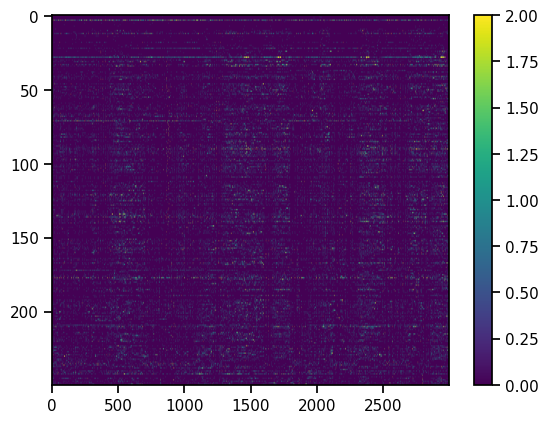

In [ ]:
# Cell 1: Fixed 10-bin windows around peaks (no merging)
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import copy

# Focus on neurons 600-900
neural_subset = copy.deepcopy(flat_data_selected[650:900,:])
n_neurons, n_bins = neural_subset.shape

# Compute population firing rate
# neural_subset = neural_subset - neural_subset.mean(axis=1, keepdims=True)
# pop_rate = neural_subset.sum(axis=0)
# pop_rate = neural_subset

# Calculate MOVING baseline using sliding window
baseline_window = 200  # Window for baseline calculation
baseline = np.zeros(shape=(n_neurons, n_bins ))

for i in range(n_bins):
    # Define window around current position
    start = max(0, i - baseline_window//2)
    end = min(n_bins, i + baseline_window//2)

    # Use 25th percentile in local window as baseline
    baseline[:, i] = np.mean(neural_subset[:, start:end], axis=1) #np.percentile(pop_rate[start:end], 25)


fig = plt.figure()
plt.imshow(baseline, aspect='auto');
plt.colorbar()


fig = plt.figure()
plt.imshow(neural_subset, aspect='auto', vmax=2);
plt.colorbar()


In [ ]:
# Calculate dynamic threshold
burst_threshold = 2.7 * baseline
burst_threshold = 2.5 * baseline

# Find peaks that exceed threshold
peaks, peak_properties = find_peaks(pop_rate, height=burst_threshold, distance=10)
peak_heights = peak_properties['peak_heights']

# CREATE FIXED WINDOWS AROUND EACH PEAK (NO MERGING)
window_size = 20  # Total window size
half_window = window_size // 2

burst_windows = []
peaks_in_windows = []  # Track which peak is in each window

for peak in peaks:
    # Create window centered on peak
    start = max(0, peak - half_window)
    end = min(n_bins, peak + half_window)
    burst_windows.append(np.arange(start, end))
    peaks_in_windows.append([peak])  # Each window has its single peak

# Get burst and non-burst indices (may overlap now)
all_burst_indices = np.unique(np.concatenate(burst_windows)) if burst_windows else np.array([])
non_burst_indices = np.setdiff1d(np.arange(n_bins), all_burst_indices)

# Visualize windowing
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                        gridspec_kw={'height_ratios': [1.2, 0.4, 3]})

# Plot 1: Population rate with peaks
axes[0].plot(pop_rate, 'k', alpha=0.7, linewidth=0.5, label='Population Rate')
axes[0].plot(baseline, 'b-', alpha=0.5, linewidth=1, label=f'Moving Baseline (window={baseline_window})')
axes[0].plot(burst_threshold, 'r-', alpha=0.7, linewidth=1, label='2.7x Baseline')

# Highlight windows (may overlap)
for burst_win in burst_windows:
    axes[0].axvspan(burst_win[0], burst_win[-1], alpha=0.1, color='red')

# ADD PEAK DOTS
axes[0].scatter(peaks, pop_rate[peaks], color='red', s=40, zorder=5,
                label=f'{len(peaks)} peaks detected', edgecolors='darkred')

axes[0].set_ylabel('Population Rate')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_title(f'Peak Detection: {len(peaks)} peaks = {len(burst_windows)} windows (fixed {window_size} bins each)')
axes[0].grid(True, alpha=0.2)

# Plot 2: Burst windows (may overlap)
for i, burst_win in enumerate(burst_windows):
    color = plt.cm.tab20(i % 20)
    axes[1].fill_between(burst_win, 0, 1, alpha=0.3, color=color)

# Add peak markers
for peak in peaks:
    axes[1].axvline(peak, color='red', alpha=0.8, linewidth=1)

axes[1].set_ylabel('Windows')
axes[1].set_ylim([0, 1])
axes[1].set_yticks([])

# Plot 3: Full raster with windows
for i, burst_win in enumerate(burst_windows):
    axes[2].axvspan(burst_win[0], burst_win[-1], alpha=0.1, color='red')

    # Add window number at center
    if i < 30:  # Only label first 30
        window_center = (burst_win[0] + burst_win[-1]) / 2
        axes[2].text(window_center, -5, f'W{i+1}',
                    ha='center', fontsize=6, color='blue', fontweight='bold')

# ADD VERTICAL LINES AT PEAKS
for peak in peaks:
    axes[2].axvline(peak, color='red', alpha=0.5, linewidth=1, linestyle='-')

# Plot all neurons
spike_times = np.where(neural_subset)
axes[2].scatter(spike_times[1], spike_times[0], s=0.8, c='k', alpha=1, rasterized=True)
axes[2].set_xlabel('Time Bins')
axes[2].set_ylabel('Neuron ID (650-900)')
axes[2].set_ylim([-10, n_neurons])
axes[2].set_title(f'Full Raster with Fixed Windows (blue=window ID, red lines=peaks)')

# Add peak numbers above
for i, peak in enumerate(peaks[:50]):
    axes[2].text(peak, n_neurons + 2, str(i+1),
                ha='center', fontsize=5, color='red', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# Cell 4: Concatenated raster of all burst windows
import numpy as np
import matplotlib.pyplot as plt

# Extract neural data for each burst window
burst_data_list = []
burst_lengths = []
peak_positions = []  # Track where peaks occur in concatenated data

cumulative_position = 0
for i, burst_win in enumerate(burst_windows):
    # Get neural data for this burst window
    burst_data = neural_subset[:, burst_win]
    burst_data_list.append(burst_data)
    burst_lengths.append(len(burst_win))

    # Find if any peaks are in this window
    peaks_in_window = [p for p in peaks if p in burst_win]
    for peak in peaks_in_window:
        # Calculate position in concatenated data
        peak_relative_pos = np.where(burst_win == peak)[0][0]
        peak_positions.append(cumulative_position + peak_relative_pos)

    cumulative_position += len(burst_win)

# Concatenate all burst windows
concatenated_bursts = np.hstack(burst_data_list) if burst_data_list else np.array([])
total_burst_bins = concatenated_bursts.shape[1] if len(burst_data_list) > 0 else 0

print(f"Concatenated {len(burst_windows)} burst windows")
print(f"Total bins in concatenated view: {total_burst_bins}")

# Create visualization
fig, axes = plt.subplots(3, 1, figsize=(20, 12),
                        gridspec_kw={'height_ratios': [1, 0.3, 4]})

# Plot 1: Population rate for concatenated bursts
concat_pop_rate = concatenated_bursts.sum(axis=0)
axes[0].plot(concat_pop_rate, 'k', linewidth=0.5)
axes[0].set_ylabel('Population Rate')
axes[0].set_title(f'Concatenated Burst Windows: {len(burst_windows)} bursts, {total_burst_bins} total bins')

# Add markers for peak positions
if peak_positions:
    axes[0].scatter(peak_positions, concat_pop_rate[peak_positions],
                   color='red', s=30, zorder=5, label='Peaks')
    axes[0].legend()

# Add vertical lines to separate bursts
cumsum_lengths = np.cumsum([0] + burst_lengths[:-1])
for i, boundary in enumerate(cumsum_lengths[1:]):
    axes[0].axvline(boundary, color='blue', alpha=0.3, linewidth=0.5)

axes[0].grid(True, alpha=0.2)

# Plot 2: Burst ID indicator
for i, (start, length) in enumerate(zip(cumsum_lengths, burst_lengths)):
    color = plt.cm.tab20(i % 20)
    axes[1].fill_between(range(start, start + length), 0, 1,
                        alpha=0.7, color=color)
    # Label every few bursts
    if i % 5 == 0:
        axes[1].text(start + length/2, 0.5, str(i+1),
                    ha='center', va='center', fontsize=8)

axes[1].set_ylabel('Burst ID')
axes[1].set_ylim([0, 1])
axes[1].set_yticks([])

# Plot 3: Concatenated raster
spike_times = np.where(concatenated_bursts)
axes[2].scatter(spike_times[1], spike_times[0], s=0.5, c='k', alpha=0.8, rasterized=True)

# Add vertical lines to separate bursts
for boundary in cumsum_lengths[1:]:
    axes[2].axvline(boundary, color='blue', alpha=0.3, linewidth=0.5)

# Add peak markers
for peak_pos in peak_positions:
    axes[2].axvline(peak_pos, color='red', alpha=0.3, linewidth=1, linestyle='--')

axes[2].set_xlabel('Concatenated Time Bins')
axes[2].set_ylabel('Neuron ID (600-900)')
axes[2].set_ylim([0, n_neurons])
axes[2].set_title('Concatenated Burst Raster (blue lines separate bursts, red dashes mark peaks)')

plt.tight_layout()
plt.show()

# Print statistics about burst patterns
print(f"\nBurst statistics:")
print(f"  Number of bursts: {len(burst_windows)}")
print(f"  Average burst duration: {np.mean(burst_lengths):.1f} bins")
print(f"  Min/Max burst duration: {np.min(burst_lengths)}/{np.max(burst_lengths)} bins")
print(f"  Total burst bins: {total_burst_bins}")
print(f"  Peaks detected: {len(peak_positions)}")

# Show first few burst durations
print(f"\nFirst 10 burst durations (bins):")
for i, length in enumerate(burst_lengths[:10]):
    print(f"  Burst {i+1}: {length} bins")



In [ ]:
# Cell 2: Compute cross-correlation matrices during and outside bursts
from scipy.stats import pearsonr

def compute_cross_correlation_matrix(spike_data, time_indices, max_lag=10):
    """Compute cross-correlation matrix for given time indices"""
    n_neurons = spike_data.shape[0]
    corr_matrix = np.zeros((n_neurons, n_neurons))

    # Extract data for specified time indices
    if len(time_indices) > 0:
        data_subset = spike_data[:, time_indices]

        # Compute pairwise correlations
        for i in range(n_neurons):
            for j in range(i, n_neurons):
                if data_subset[i].sum() > 5 and data_subset[j].sum() > 5:  # Min activity threshold
                    corr = np.corrcoef(data_subset[i], data_subset[j])[0, 1]
                    if not np.isnan(corr):
                        corr_matrix[i, j] = corr
                        corr_matrix[j, i] = corr

    return corr_matrix

# Compute correlation matrices
print("Computing burst correlation matrix...")
burst_corr = compute_cross_correlation_matrix(neural_subset, all_burst_indices)

print("Computing non-burst correlation matrix...")
non_burst_corr = compute_cross_correlation_matrix(neural_subset, non_burst_indices)

# Visualize correlation matrices
fig, axes = plt.subplots(1, 3, figsize=(24, 12))

# Plot burst correlations
im1 = axes[0].imshow(burst_corr, cmap='RdBu_r',  vmin=-0.2, vmax=0.2,  aspect='auto')
axes[0].set_title(f'During Bursts\n({len(all_burst_indices)} bins)')
axes[0].set_xlabel('Neuron ID')
axes[0].set_ylabel('Neuron ID')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Plot non-burst correlations
im2 = axes[1].imshow(non_burst_corr, cmap='RdBu_r', vmin=-0.2, vmax=0.2, aspect='auto')
axes[1].set_title(f'Outside Bursts\n({len(non_burst_indices)} bins)')
axes[1].set_xlabel('Neuron ID')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

# Plot difference
diff_corr = burst_corr - non_burst_corr
im3 = axes[2].imshow(diff_corr, cmap='RdBu_r', vmin=-0.1, vmax=0.1, aspect='auto')
axes[2].set_title('Difference\n(Burst - Non-burst)')
axes[2].set_xlabel('Neuron ID')
plt.colorbar(im3, ax=axes[2], fraction=0.046)

plt.suptitle('Cross-Correlation Analysis: Burst vs Non-Burst Periods')
plt.tight_layout()
plt.show()


In [ ]:
# Cell 5: Compute group firing order for each burst window
import numpy as np
from collections import Counter

# Split neurons into 6 groups of 50 consecutive neurons
n_groups = 5
neurons_per_group = 50
groups = []
for g in range(n_groups):
    start_neuron = g * neurons_per_group
    end_neuron = start_neuron + neurons_per_group
    groups.append(np.arange(start_neuron, end_neuron))

print(f"Created {n_groups} groups of {neurons_per_group} neurons each")
for g, group in enumerate(groups):
    print(f"  Group {g+1}: neurons {group[0]}-{group[-1]}")

# Extract firing order for each burst window
burst_sequences = []
burst_peak_times = []
burst_peak_amplitudes = []

for burst_idx, burst_win in enumerate(burst_windows):
    # Get neural data for this burst window
    burst_data = neural_subset[:, burst_win]

    # Calculate group activity (sum across neurons in each group)
    group_activities = np.zeros((n_groups, len(burst_win)))
    for g, group_neurons in enumerate(groups):
        group_activities[g] = burst_data[group_neurons].sum(axis=0)

    # Find peak time for each group
    peak_times = []
    peak_amps = []
    for g in range(n_groups):
        if group_activities[g].max() > 0:  # Check if group is active
            peak_time = np.argmax(group_activities[g])
            peak_amp = group_activities[g].max()
            peak_times.append((g+1, peak_time, peak_amp))  # Store group number (1-indexed), time, amplitude
            peak_amps.append(peak_amp)
        else:
            peak_times.append((g+1, -1, 0))  # Inactive group
            peak_amps.append(0)

    # Sort groups by peak time (excluding inactive groups)
    active_groups = [(g, t, a) for g, t, a in peak_times if t >= 0]
    active_groups.sort(key=lambda x: x[1])  # Sort by peak time

    # Extract sequence (order of group numbers)
    sequence = tuple([g for g, t, a in active_groups])

    burst_sequences.append(sequence)
    burst_peak_times.append(peak_times)
    burst_peak_amplitudes.append(peak_amps)

# Count sequence frequencies
sequence_counter = Counter(burst_sequences)
most_common_sequences = sequence_counter.most_common(20)

print(f"\n=== SEQUENCE ANALYSIS RESULTS ===")
print(f"Total bursts analyzed: {len(burst_sequences)}")
print(f"Unique sequences found: {len(sequence_counter)}")

print(f"\nTop 10 most common sequences:")
for i, (seq, count) in enumerate(most_common_sequences[:10]):
    percentage = (count / len(burst_sequences)) * 100
    print(f"  {i+1}. {seq}: {count} times ({percentage:.1f}%)")

# Find most common sequence length
sequence_lengths = [len(seq) for seq in burst_sequences]
print(f"\nSequence lengths:")
print(f"  Mean: {np.mean(sequence_lengths):.1f} groups")
print(f"  Min/Max: {np.min(sequence_lengths)}/{np.max(sequence_lengths)} groups")

# Check which groups are most often first/last
first_groups = [seq[0] for seq in burst_sequences if len(seq) > 0]
last_groups = [seq[-1] for seq in burst_sequences if len(seq) > 0]

print(f"\nGroups most often FIRST in sequence:")
for group, count in Counter(first_groups).most_common(3):
    print(f"  Group {group}: {count} times ({count/len(first_groups)*100:.1f}%)")

print(f"\nGroups most often LAST in sequence:")
for group, count in Counter(last_groups).most_common(3):
    print(f"  Group {group}: {count} times ({count/len(last_groups)*100:.1f}%)")

# Create a transition matrix (which group follows which)
transition_counts = np.zeros((n_groups+1, n_groups+1))  # +1 for "start" state
for seq in burst_sequences:
    if len(seq) > 0:
        transition_counts[0, seq[0]-1] += 1  # Start -> first group
        for i in range(len(seq)-1):
            transition_counts[seq[i], seq[i+1]] += 1  # Group -> next group

# Normalize to get probabilities
transition_probs = transition_counts / (transition_counts.sum(axis=1, keepdims=True) + 1e-10)

print(f"\nAnalysis complete. Ready for visualization.")

In [ ]:
# Cell 7: Full concatenated burst raster with active group coloring
import matplotlib.pyplot as plt
import numpy as np

# Extract neural data for all burst windows (concatenated)
burst_data_list = []
burst_lengths = []
peak_positions_global = []
burst_boundaries = [0]

for i, burst_win in enumerate(burst_windows):
    burst_data = neural_subset[:, burst_win]
    burst_data_list.append(burst_data)
    burst_lengths.append(len(burst_win))
    burst_boundaries.append(burst_boundaries[-1] + len(burst_win))

# Concatenate all bursts
concatenated_bursts = np.hstack(burst_data_list) if burst_data_list else np.array([])
total_bins = concatenated_bursts.shape[1] if len(burst_data_list) > 0 else 0

print(f"Concatenated {len(burst_windows)} bursts into {total_bins} total bins")

# Calculate group activities for all concatenated data
group_activities_concat = np.zeros((n_groups, total_bins))
for g, group_neurons in enumerate(groups):
    group_activities_concat[g] = concatenated_bursts[group_neurons].sum(axis=0)

# Color palette for groups
group_colors = plt.cm.tab10(np.linspace(0, 1, n_groups))

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(24, 10),
                        gridspec_kw={'height_ratios': [3, 1]})

# Top: Raster with active group coloring
ax_raster = axes[0]

# First plot all spikes in light gray as background
all_spikes = np.where(concatenated_bursts)
ax_raster.scatter(all_spikes[1], all_spikes[0], s=10, c='lightgray',
                 alpha=0.2, rasterized=True)

# For each time bin, color spikes of the most active group
print("Coloring active groups...")
for t in range(0, total_bins, 1):  # Process every bin
    if t % 500 == 0:
        print(f"  Processing bin {t}/{total_bins}")

    if group_activities_concat[:, t].max() > 0:
        active_group = np.argmax(group_activities_concat[:, t])
        group_neurons = groups[active_group]

        # Find active neurons in this group at this time
        active_neurons = np.where(concatenated_bursts[group_neurons, t] > 0)[0]
        if len(active_neurons) > 0:
            neuron_ids = active_neurons + active_group * neurons_per_group
            time_points = np.full(len(active_neurons), t)
            ax_raster.scatter(time_points, neuron_ids, s=10,
                            c=[group_colors[active_group]], alpha=0.8)

# Add group boundaries
for g in range(1, n_groups):
    ax_raster.axhline(g * neurons_per_group, color='gray', linewidth=0.5, alpha=0.3)

# Add burst boundaries
for boundary in burst_boundaries[1:-1]:
    ax_raster.axvline(boundary, color='blue', alpha=0.4, linewidth=0.5)

# Add group labels
for g in range(n_groups):
    ax_raster.text(-20, (g+0.5) * neurons_per_group, f'G{g+1}',
                  color=group_colors[g], fontsize=10, fontweight='bold',
                  ha='right', va='center')

ax_raster.set_xlim([0, total_bins])
ax_raster.set_ylim([0, n_neurons])
ax_raster.set_ylabel('Neuron ID')
ax_raster.set_title(f'Concatenated Burst Raster ({len(burst_windows)} bursts, {total_bins} bins)\n' +
                   'Colored by Active Group at Each Time')

# Bottom: Group activity traces
ax_activity = axes[1]

# Plot all group activities
for g in range(n_groups):
    ax_activity.plot(group_activities_concat[g], color=group_colors[g],
                    linewidth=0.8, alpha=0.7, label=f'G{g+1}')


# Add burst boundaries
for boundary in burst_boundaries[1:-1]:
    ax_activity.axvline(boundary, color='blue', alpha=0.5, linewidth=0.5)

ax_activity.set_xlabel('Concatenated Time Bins')
ax_activity.set_ylabel('Group Activity')
ax_activity.set_xlim([0, total_bins])
ax_activity.legend(loc='upper right', fontsize=9, ncol=6)

plt.tight_layout()
plt.show()

# Compute and print statistics
print(f"\n=== CONCATENATED BURST STATISTICS ===")
print(f"Total bursts: {len(burst_windows)}")
print(f"Total bins: {total_bins}")
print(f"Average burst length: {np.mean(burst_lengths):.1f} bins")

# Calculate dominant group at each time
dominant_groups = np.argmax(group_activities_concat, axis=0)
for g in range(n_groups):
    dominance_count = np.sum(dominant_groups == g)
    print(f"Group {g+1} dominant: {dominance_count} bins ({dominance_count/total_bins*100:.1f}%)")

In [ ]:
# Cell 7: Concatenated burst raster - shaded by sequence, spikes colored by active group
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Get unique sequences and assign colors
unique_sequences = list(set(burst_sequences))
sequence_colors = plt.cm.tab20(np.linspace(0, 1, len(unique_sequences)))
sequence_to_color = {seq: sequence_colors[i] for i, seq in enumerate(unique_sequences)}

# Count sequence frequencies for legend
sequence_counts = Counter(burst_sequences)
top_sequences = sequence_counts.most_common(10)

# Extract and concatenate burst data
burst_data_list = []
burst_boundaries = [0]

for burst_win in burst_windows:
    burst_data = neural_subset[:, burst_win]
    burst_data_list.append(burst_data)
    burst_boundaries.append(burst_boundaries[-1] + len(burst_win))

concatenated_bursts = np.hstack(burst_data_list) if burst_data_list else np.array([])
total_bins = concatenated_bursts.shape[1]

# Calculate group activities
group_activities_concat = np.zeros((n_groups, total_bins))
for g, group_neurons in enumerate(groups):
    group_activities_concat[g] = concatenated_bursts[group_neurons].sum(axis=0)

# Group colors for spike coloring
group_colors = plt.cm.Set1(np.linspace(0, 1, n_groups))

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(24, 10),
                        gridspec_kw={'height_ratios': [3, 1]})

# Top: Raster with sequence shading and active group spike coloring
ax_raster = axes[0]

# First plot all spikes in light gray
all_spikes = np.where(concatenated_bursts)
ax_raster.scatter(all_spikes[1], all_spikes[0], s=10, c='lightgray',
                 alpha=0.2, rasterized=True)

# Process each burst window
current_bin = 0
for burst_idx, burst_win in enumerate(burst_windows):
    burst_length = len(burst_win)
    burst_bins = range(current_bin, current_bin + burst_length)
    sequence = burst_sequences[burst_idx]

    # Add background shading based on sequence
    seq_color = sequence_to_color[sequence]
    ax_raster.axvspan(current_bin, current_bin + burst_length - 1,
                      color=seq_color, alpha=0.15, zorder=0)

    # Color spikes by most active group at each time
    for t_local, t_global in enumerate(burst_bins):
        if group_activities_concat[:, t_global].max() > 0:
            active_group = np.argmax(group_activities_concat[:, t_global])
            group_neurons = groups[active_group]

            # Find active neurons in this group at this time
            active_neurons = np.where(concatenated_bursts[group_neurons, t_global] > 0)[0]
            if len(active_neurons) > 0:
                neuron_ids = active_neurons + active_group * neurons_per_group
                ax_raster.scatter(np.full(len(neuron_ids), t_global),
                                neuron_ids, s=10, c=[group_colors[active_group]],
                                alpha=0.8, zorder=2)

    current_bin += burst_length

# Add burst boundaries
for boundary in burst_boundaries[1:-1]:
    ax_raster.axvline(boundary, color='black', alpha=0.2, linewidth=0.3)

# Add group boundaries
for g in range(1, n_groups):
    ax_raster.axhline(g * neurons_per_group, color='gray', linewidth=0.5, alpha=0.3)

# Add group labels
for g in range(n_groups):
    ax_raster.text(-20, (g+0.5) * neurons_per_group, f'G{g+1}',
                  color=group_colors[g], fontsize=10, fontweight='bold',
                  ha='right', va='center')

ax_raster.set_xlim([0, total_bins])
ax_raster.set_ylim([0, n_neurons])
ax_raster.set_ylabel('Neuron ID')
ax_raster.set_title(f'Concatenated Bursts: Background shaded by sequence type, spikes colored by active group\n' +
                   f'{len(unique_sequences)} unique sequences across {len(burst_windows)} bursts')

# Bottom: Group activities with sequence shading
ax_activity = axes[1]

# Plot group activities
for g in range(n_groups):
    ax_activity.plot(group_activities_concat[g], color=group_colors[g],
                    linewidth=0.8, alpha=0.7, label=f'G{g+1}')

# Add sequence shading
current_bin = 0
for burst_idx, burst_win in enumerate(burst_windows):
    burst_length = len(burst_win)
    sequence = burst_sequences[burst_idx]
    seq_color = sequence_to_color[sequence]

    ax_activity.axvspan(current_bin, current_bin + burst_length - 1,
                       color=seq_color, alpha=0.15, zorder=0)

    current_bin += burst_length

# Add burst boundaries
for boundary in burst_boundaries[1:-1]:
    ax_activity.axvline(boundary, color='black', alpha=0.2, linewidth=0.3)

ax_activity.set_xlabel('Concatenated Time Bins')
ax_activity.set_ylabel('Group Activity')
ax_activity.set_xlim([0, total_bins])

# Create legend showing top sequences
from matplotlib.patches import Patch
legend_elements = []
for seq, count in top_sequences[:5]:
    seq_color = sequence_to_color[seq]
    legend_elements.append(Patch(facecolor=seq_color, alpha=0.3,
                                label=f'{seq} ({count}x)'))
ax_activity.legend(handles=legend_elements, loc='upper right',
                  title='Top Sequences', fontsize=8)

# Add group legend
ax_raster.legend(loc='upper right', fontsize=8, ncol=n_groups)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n=== SEQUENCE STATISTICS ===")
print(f"Total unique sequences: {len(unique_sequences)}")
print(f"Total bursts: {len(burst_windows)}")
print(f"\nTop 10 most common sequences:")
for i, (seq, count) in enumerate(top_sequences[:10]):
    print(f"  {i+1}. {seq}: {count} times ({count/len(burst_sequences)*100:.1f}%)")

## Sequence generator

In [ ]:
# Cell 1: Data Generation
import numpy as np

class SequenceGenerator:
    def __init__(self,
                 n_neurons=100,
                 n_sequence_types=3,
                 neurons_per_sequence=20,
                 sequence_rate=0.002,      # sequences per ms
                 background_rate=0.0005,    # spikes per ms per neuron
                 sequence_duration=50,     # ms
                 amplitude_mean=30,        # expected spikes per sequence
                 amplitude_variance=5,
                 participation_noise=0.0,  # probability neuron fails to fire
                 timing_jitter=2.0):       # ms std of timing noise

        self.n_neurons = n_neurons
        self.n_sequence_types = n_sequence_types
        self.sequence_rate = sequence_rate
        self.background_rate = background_rate
        self.participation_noise = participation_noise

        # Define DISJOINT participation (no neuron in multiple sequences)
        self.participation = np.zeros((n_sequence_types, n_neurons))
        self.neuron_sequence_id = np.full(n_neurons, -1)  # -1 means not in any sequence

        # Randomly assign neurons to sequences (no overlap)
        available_neurons = np.arange(n_neurons)
        np.random.shuffle(available_neurons)

        for r in range(n_sequence_types):
            start_idx = r * neurons_per_sequence
            end_idx = start_idx + neurons_per_sequence
            if end_idx <= n_neurons:
                selected = available_neurons[start_idx:end_idx]
                self.participation[r, selected] = 1.0 / neurons_per_sequence
                self.neuron_sequence_id[selected] = r

        # Define SEQUENTIAL temporal structure
        self.offsets = np.zeros((n_sequence_types, n_neurons))
        for r in range(n_sequence_types):
            active_neurons = np.where(self.participation[r] > 0)[0]
            # Sequential firing with uniform spacing
            times = np.linspace(0, sequence_duration, len(active_neurons))
            self.offsets[r, active_neurons] = times

        self.widths = np.ones((n_sequence_types, n_neurons)) * timing_jitter

        # Amplitude parameters
        self.amplitude_beta = amplitude_mean / amplitude_variance
        self.amplitude_alpha = amplitude_mean * self.amplitude_beta

        # Store sequence events for analysis
        self.sequence_events = []

    def generate(self, duration_ms=1000):
        """Generate spike trains with embedded sequences"""

        # 1. Generate background spikes
        n_background = np.random.poisson(self.background_rate * duration_ms * self.n_neurons)
        background_times = np.random.uniform(0, duration_ms, n_background)
        background_neurons = np.random.randint(0, self.n_neurons, n_background)

        # 2. Generate sequences
        n_sequences = np.random.poisson(self.sequence_rate * duration_ms)
        self.sequence_events = []  # Reset sequence event log

        sequence_times = []
        sequence_neurons = []

        for _ in range(n_sequences):
            # Sample sequence type
            seq_type = np.random.randint(0, self.n_sequence_types)

            # Sample sequence start time
            seq_start = np.random.uniform(0, duration_ms)

            # Sample amplitude
            amplitude = np.random.gamma(self.amplitude_alpha, 1/self.amplitude_beta)

            # Log this sequence event
            self.sequence_events.append({
                'type': seq_type,
                'start_time': seq_start,
                'amplitude': amplitude
            })

            # Generate spikes for this sequence
            for neuron_id in range(self.n_neurons):
                if self.participation[seq_type, neuron_id] > 0:
                    if np.random.random() > self.participation_noise:
                        n_spikes = np.random.poisson(amplitude * self.participation[seq_type, neuron_id])

                        for _ in range(n_spikes):
                            spike_time = seq_start + self.offsets[seq_type, neuron_id]
                            spike_time += np.random.normal(0, self.widths[seq_type, neuron_id])

                            if 0 <= spike_time < duration_ms:
                                sequence_times.append(spike_time)
                                sequence_neurons.append(neuron_id)

        # Combine all spikes
        all_times = np.concatenate([background_times, sequence_times])
        all_neurons = np.concatenate([background_neurons, sequence_neurons])

        # Sort by time
        sort_idx = np.argsort(all_times)

        return all_times[sort_idx], all_neurons[sort_idx].astype(int)

# Generate synthetic data
# np.random.seed(42)

n_neurons=60
n_sequence_types=6
neurons_per_sequence=10
sequence_rate=0.008
background_rate=0.02
timing_jitter=1.5
duration_ms = 3000

generator = SequenceGenerator(
    n_neurons=n_neurons,
    n_sequence_types=n_sequence_types,
    neurons_per_sequence=neurons_per_sequence,
    sequence_rate=sequence_rate,
    background_rate=background_rate,
    timing_jitter=timing_jitter
)

spike_times, spike_neurons = generator.generate(duration_ms=duration_ms)
print(f"Generated {len(spike_times)} spikes")
print(f"Generated {len(generator.sequence_events)} sequence events")

In [ ]:
# Cell 2: Visualization (updated for new parameters)
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Extended color palette for 6 sequence types
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'cyan']

# Top: Regular raster plot
# Smaller markers and lower alpha due to higher background rate
ax1.scatter(spike_times, spike_neurons, s=2, c='black', alpha=0.8)
ax1.set_ylabel('Neuron ID')
ax1.set_title('Raw Raster Plot')
ax1.set_xlim(0, 2000)
ax1.set_ylim(-1, generator.n_neurons)

# Mark sequence events with thicker lines due to more visual clutter
for event in generator.sequence_events:
    ax1.axvline(event['start_time'], color=colors[event['type']],
                alpha=0.4, linestyle='--', linewidth=1)

# Bottom: Sequence-sorted raster plot
# Sort neurons by: 1) sequence type, 2) temporal offset within sequence
sort_order = []

# First add neurons sorted by sequence and timing
for seq_type in range(generator.n_sequence_types):
    neurons_in_seq = np.where(generator.neuron_sequence_id == seq_type)[0]
    if len(neurons_in_seq) > 0:
        # Sort by offset within sequence
        offsets = generator.offsets[seq_type, neurons_in_seq]
        sorted_neurons = neurons_in_seq[np.argsort(offsets)]
        sort_order.extend(sorted_neurons)

# Then add neurons not in any sequence (background neurons)
background_neurons = np.where(generator.neuron_sequence_id == -1)[0]
sort_order.extend(background_neurons)

# Create mapping from original to sorted neuron index
neuron_to_sorted = {n: i for i, n in enumerate(sort_order)}
spike_neurons_sorted = [neuron_to_sorted[n] for n in spike_neurons]

# Color spikes by sequence membership for better visibility
spike_colors = []
for n in spike_neurons:
    seq_id = generator.neuron_sequence_id[n]
    if seq_id >= 0:
        spike_colors.append(colors[seq_id])
    else:
        spike_colors.append('gray')

ax2.scatter(spike_times, spike_neurons_sorted, s=2, c=spike_colors, alpha=0.8)
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Neuron ID (sorted)')
ax2.set_title('Sequence-Sorted Raster Plot (colored by sequence membership)')
ax2.set_xlim(0, 2000)
ax2.set_ylim(-1, generator.n_neurons)

# Mark sequence events
for event in generator.sequence_events:
    ax2.axvline(event['start_time'], color=colors[event['type']],
                alpha=0.6, linestyle='--', linewidth=1)

# Add sequence boundaries and labels
n_cumulative = 0
for seq_type in range(generator.n_sequence_types):
    n_in_seq = np.sum(generator.neuron_sequence_id == seq_type)
    if n_in_seq > 0:
        # Add boundary line
        ax2.axhline(n_cumulative - 0.5, color='black', linestyle='-', linewidth=1, alpha=0.7)
        # Add colored background patch for better visibility
        ax2.axhspan(n_cumulative, n_cumulative + n_in_seq,
                   alpha=0.05, color=colors[seq_type])
        # Label sequence type
        ax2.text(-50, n_cumulative + n_in_seq/2, f'Seq {seq_type+1}',
                va='center', ha='right', fontsize=9, color=colors[seq_type],
                fontweight='bold')
        n_cumulative += n_in_seq

# Mark background neurons section
if np.sum(generator.neuron_sequence_id == -1) > 0:
    ax2.axhline(n_cumulative - 0.5, color='black', linestyle='-', linewidth=1, alpha=0.7)
    ax2.text(-50, n_cumulative + np.sum(generator.neuron_sequence_id == -1)/2, 'BG',
            va='center', ha='right', fontsize=9, color='gray', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 50)
print("SEQUENCE SUMMARY")
print("=" * 50)
for seq_type in range(generator.n_sequence_types):
    n_neurons = np.sum(generator.neuron_sequence_id == seq_type)
    print(f"Sequence type {seq_type+1}: {n_neurons} neurons (color: {colors[seq_type]})")
print(f"Background neurons: {np.sum(generator.neuron_sequence_id == -1)}")
print(f"\nTotal spikes: {len(spike_times)}")
print(f"Sequence events: {len(generator.sequence_events)}")

# Count spikes by type
seq_spike_counts = {i: 0 for i in range(generator.n_sequence_types)}
bg_spike_count = 0
for n in spike_neurons:
    seq_id = generator.neuron_sequence_id[n]
    if seq_id >= 0:
        seq_spike_counts[seq_id] += 1
    else:
        bg_spike_count += 1


## Rastermap

In [ ]:
pip install rastermap

In [ ]:
#%% Rastermap Analysis - Revealing Functional Organization
print("="*60)
print("RASTERMAP ANALYSIS - FUNCTIONAL ORGANIZATION")
print("="*60)
n_trials_subset = 300
# First check how many neurons we have
print(f"Total neurons available: {len(unique_neurons)}")
print(f"Trials used: {n_trials_subset}")

#%% Prepare Feature Vectors for Rastermap

def create_feature_vectors_for_rastermap(trial_windows, trial_labels, bin_ms=25):
    """
    Create feature vectors following the paper's approach:
    - Create PETHs for different trial conditions
    - Concatenate into long feature vector per neuron
    - Z-score normalize
    """
    n_trials, n_neurons, n_time_bins = trial_windows.shape

    # Rebin to coarser resolution (25ms bins like paper uses 125ms but we'll use 25ms for more detail)
    bins_to_combine = bin_ms // 5  # Original is 5ms bins
    n_new_bins = n_time_bins // bins_to_combine

    trial_windows_rebinned = trial_windows.reshape(n_trials, n_neurons, n_new_bins, bins_to_combine).sum(axis=3)

    print(f"Rebinned from {n_time_bins} bins to {n_new_bins} bins ({bin_ms}ms each)")

    # Create PETHs for different conditions
    peths_dict = {}

    # 1. By choice direction
    left_choice = [i for i, l in enumerate(trial_labels) if l['choice'] == 'left']
    right_choice = [i for i, l in enumerate(trial_labels) if l['choice'] == 'right']

    if len(left_choice) > 0:
        peths_dict['choice_left'] = trial_windows_rebinned[left_choice].mean(axis=0)
    if len(right_choice) > 0:
        peths_dict['choice_right'] = trial_windows_rebinned[right_choice].mean(axis=0)

    # 2. By reaction time (fast vs slow)
    rts = [l['reaction_time'] for l in trial_labels]
    rt_median = np.median(rts)
    fast_trials = [i for i, l in enumerate(trial_labels) if l['reaction_time'] < rt_median]
    slow_trials = [i for i, l in enumerate(trial_labels) if l['reaction_time'] >= rt_median]

    if len(fast_trials) > 0:
        peths_dict['rt_fast'] = trial_windows_rebinned[fast_trials].mean(axis=0)
    if len(slow_trials) > 0:
        peths_dict['rt_slow'] = trial_windows_rebinned[slow_trials].mean(axis=0)

    # 3. Grand average
    peths_dict['all_trials'] = trial_windows_rebinned.mean(axis=0)

    # Concatenate PETHs into feature vectors
    feature_vectors = []
    for neuron_idx in range(n_neurons):
        neuron_vector = []
        for peth_name, peth_data in peths_dict.items():
            neuron_vector.extend(peth_data[neuron_idx, :])

        # Z-score normalize (with small epsilon to avoid division by zero)
        neuron_vector = np.array(neuron_vector)
        std = np.std(neuron_vector)
        if std > 0:
            neuron_vector = (neuron_vector - np.mean(neuron_vector)) / std
        else:
            neuron_vector = neuron_vector - np.mean(neuron_vector)

        feature_vectors.append(neuron_vector)

    feature_matrix = np.array(feature_vectors)

    print(f"Created feature matrix: {feature_matrix.shape} (neurons × features)")
    print(f"Feature vector length: {feature_matrix.shape[1]} timepoints")

    return feature_matrix, peths_dict, trial_windows_rebinned

# Create feature vectors
feature_matrix, peths_dict, trial_windows_rebinned = create_feature_vectors_for_rastermap(
    trial_windows[:n_trials_subset],
    trial_labels[:n_trials_subset]
)

#%% Apply Rastermap

# Install if needed: pip install rastermap
try:
    from rastermap import Rastermap
except ImportError:
    print("Installing rastermap...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'rastermap'])
    from rastermap import Rastermap

def apply_rastermap(feature_matrix, n_clusters=40):
    """
    Apply rastermap to order neurons by functional similarity
    """
    print(f"\nApplying rastermap with {n_clusters} clusters...")

    # Initialize rastermap
    model = Rastermap(n_clusters=n_clusters,
                      locality=0.1,  # How local the ordering should be
                      time_lag_window=0)  # No time lag for our feature vectors

    # Fit model
    model.fit(feature_matrix)

    # Get ordering
    neuron_ordering = model.isort

    print(f"✓ Rastermap complete")

    return neuron_ordering, model

# Apply rastermap
neuron_ordering, rastermap_model = apply_rastermap(feature_matrix)


In [ ]:
def plot_rastermap_results(trial_windows_rebinned, neuron_ordering, trial_labels,
                           unique_neurons, window_ms=[-500, 2000]):
    """
    Create visualization similar to Figure 3 from the paper
    """
    n_trials, n_neurons, n_time_bins = trial_windows_rebinned.shape

    # Create time axis
    time_axis = np.linspace(window_ms[0], window_ms[1], n_time_bins)

    fig = plt.figure(figsize=(20, 12))

    # Main rastermap plot - average across trial types
    ax1 = plt.subplot(2, 3, (1, 3))

    # Create activity matrix for different trial conditions
    conditions = {
        'Left choice': [i for i, l in enumerate(trial_labels) if l['choice'] == 'left'],
        'Right choice': [i for i, l in enumerate(trial_labels) if l['choice'] == 'right']
    }

    # Plot each condition side by side
    combined_matrix = []
    time_labels = []

    for cond_name, trial_indices in conditions.items():
        if len(trial_indices) > 0:
            # Average activity for this condition
            avg_activity = trial_windows_rebinned[trial_indices].mean(axis=0)
            # Apply neuron ordering
            avg_activity_ordered = avg_activity[neuron_ordering, :]
            combined_matrix.append(avg_activity_ordered)
            time_labels.extend([cond_name] * n_time_bins)

    if combined_matrix:
        combined_matrix = np.hstack(combined_matrix)

        # Normalize for visualization
        vmax = np.percentile(combined_matrix, 99)

        im = ax1.imshow(combined_matrix, aspect='auto', cmap='hot',
                       vmin=0, vmax=vmax, interpolation='nearest')

        ax1.set_xlabel('Time relative to stimulus (ms)')
        ax1.set_ylabel('Neurons (ordered by functional similarity)')
        ax1.set_title('Neural Activity Ordered by Functional Similarity\n(Left: left choice trials | Right: right choice trials)')

        # Add time markers
        ax1.axvline(x=n_time_bins, color='white', linestyle='--', alpha=0.5)

        # Add stimulus onset marker
        stim_onset_bin = int((-window_ms[0] / (window_ms[1] - window_ms[0])) * n_time_bins)
        ax1.axvline(x=stim_onset_bin, color='cyan', linestyle='-', alpha=0.5, label='Stim onset')
        ax1.axvline(x=stim_onset_bin + n_time_bins, color='cyan', linestyle='-', alpha=0.5)

        plt.colorbar(im, ax=ax1, label='Firing rate (Hz)')

    # Plot feature matrix (ordered)
    ax2 = plt.subplot(2, 3, 4)
    feature_matrix_ordered = feature_matrix[neuron_ordering, :]
    im2 = ax2.imshow(feature_matrix_ordered, aspect='auto', cmap='RdBu_r',
                    vmin=-2, vmax=2)
    ax2.set_xlabel('Feature dimensions')
    ax2.set_ylabel('Neurons (ordered)')
    ax2.set_title('Feature Vectors (Z-scored)')
    plt.colorbar(im2, ax=ax2, label='Z-score')

    # Plot ordering visualization instead of embedding
    ax3 = plt.subplot(2, 3, 5)

    # Show the ordering as a 1D plot
    ax3.plot(neuron_ordering, np.arange(len(neuron_ordering)), 'b.', markersize=1)
    ax3.set_xlabel('Original neuron index')
    ax3.set_ylabel('New position (ordered)')
    ax3.set_title('Neuron Reordering by Rastermap')
    ax3.grid(True, alpha=0.3)

    # Summary statistics
    ax4 = plt.subplot(2, 3, 6)
    ax4.axis('off')

    summary_text = f"""
    Rastermap Analysis Summary
    -------------------------
    Total neurons: {n_neurons}
    Total trials: {n_trials}
    Time bins: {n_time_bins}
    Bin size: 25ms

    Conditions analyzed:
    - Left choice: {len(conditions['Left choice'])} trials
    - Right choice: {len(conditions['Right choice'])} trials

    Feature vector dimensions: {feature_matrix.shape[1]}

    Key observations:
    - Neurons are ordered by functional similarity
    - Clear functional blocks visible
    - Activity patterns reveal temporal dynamics
    """

    ax4.text(0.1, 0.9, summary_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace')

    plt.tight_layout()
    plt.show()

    return fig

# Re-run the visualization with the fixed function
rastermap_fig = plot_rastermap_results(
    trial_windows_rebinned,
    neuron_ordering,
    trial_labels[:n_trials_subset],
    unique_neurons,
    window_ms=[-500, 2000]
)

## Extra Stuff

### Hard reset IBL ONE Info

In [ ]:
import os
import shutil
from pathlib import Path

# 1. Remove ONE cache directories
one_cache_locations = [
    Path.home() / '.one',  # Default cache location
    Path.home() / 'Downloads' / 'ONE',  # Alternative location
    Path.home() / '.cache' / 'one',  # Linux cache location
]

for cache_dir in one_cache_locations:
    if cache_dir.exists():
        print(f"Removing: {cache_dir}")
        shutil.rmtree(cache_dir)

# 2. Remove Alyx/IBL configuration files
config_locations = [
    Path.home() / '.alyx',  # Alyx config
    Path.home() / '.ibl',  # IBL config
    Path.home() / '.one_params',  # ONE parameters
    Path.home() / '.alyx_credentials',  # Stored credentials
]

for config_file in config_locations:
    if config_file.exists():
        print(f"Removing: {config_file}")
        if config_file.is_dir():
            shutil.rmtree(config_file)
        else:
            config_file.unlink()

# 3. Clear any environment variables (if set)
env_vars = ['ONE_CACHE_DIR', 'ALYX_URL', 'ALYX_USERNAME', 'ALYX_PASSWORD']
for var in env_vars:
    if var in os.environ:
        print(f"Clearing environment variable: {var}")
        del os.environ[var]

print("\n✓ All ONE/IBL settings have been cleared!")
print("You can now start fresh with:")